# AI Image Forensics — Unpaired 800 + 800 Dataset Analysis (v1)

This notebook is the **unpaired-dataset continuation** of the earlier paired 8-image forensic analysis.

### Dataset
- `dataset/real/` — 800 real images (`real_00000.png` ...)
- `dataset/fake/` — 800 AI-generated images (`fake_00000.png` ...)
- `dataset/manifest.csv` — labels and source-row metadata
- All images are expected to be **256 × 256 PNG** files.

### Main goal
Identify which low-level forensic representations show reliable differences between the real and AI-generated classes, while avoiding conclusions that depend on artificial real/fake pairing.

### Analyses retained from the previous notebook
- FFT / Fourier frequency analysis
- 3-level Haar DWT
- 8×8 block DCT
- Gaussian high-pass residuals
- 2×2 cross-difference
- Synthbuster-inspired periodic FFT features
- Sobel gradient, Laplacian, Canny and contour analysis
- LBP texture analysis
- GLCM texture analysis
- RGB / intensity / HSV / entropy
- Error Level Analysis (ELA)
- Exploratory color-quaternion wavelet features

### Statistical design for this dataset
Because the images are **unpaired**, this notebook does **not** calculate paired deltas, paired Cohen's `dz`, or exact paired sign-flip tests. Instead it uses:

1. Real/fake distribution summaries
2. Welch's independent-samples t-test
3. Mann–Whitney U test
4. Hedges' g effect size
5. Cliff's delta
6. Single-feature ROC-AUC
7. Benjamini–Hochberg FDR correction
8. Feature correlation / redundancy analysis
9. PCA visualization of the scalar forensic feature space

The statistical results are evidence about this dataset, not proof of a universal AI-image signature. The later CNN experiments should use held-out or generator-aware evaluation where the metadata permits it.

In [1]:
# Install once in the SAME Python environment/kernel used by this notebook:
# %pip install -U torch torchvision kornia ptwt torch-dct numpy scipy scikit-image opencv-python pandas matplotlib scikit-learn

from pathlib import Path
import math

import torch
import torch.nn.functional as F
from torchvision.io import decode_image, encode_jpeg, ImageReadMode
from torchvision.transforms import v2
import kornia
import kornia.filters as KF
import ptwt
import torch_dct as tdct
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from skimage.feature import graycomatrix, graycoprops
from sklearn.decomposition import PCA
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# The dataset shown in the project directory is already 256 x 256.
# We therefore DO NOT upscale it to 512 x 512: upscaling would introduce
# interpolation structure that could contaminate low-level forensic features.
ANALYSIS_SIZE = (256, 256)

DATASET_DIR = Path("dataset")
REAL_DIR = DATASET_DIR / "real"
FAKE_DIR = DATASET_DIR / "fake"
MANIFEST_PATH = DATASET_DIR / "manifest.csv"
OUT_DIR = Path("analysis_800_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SHOW_VISUALS = False
SAVE_DEMO_VISUALS = True
SAVE_ALL_PAIR_FIGURES = SAVE_DEMO_VISUALS
N_DEMO_PER_CLASS = 2

IMAGE_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp"}

print("PyTorch:", torch.__version__)
print("TorchVision:", __import__("torchvision").__version__)
print("Kornia:", kornia.__version__)
print("Device:", DEVICE)
if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
print("Dataset directory:", DATASET_DIR.resolve())

PyTorch: 2.13.0+cu130
TorchVision: 0.28.0+cu130
Kornia: 0.8.3
Device: cuda
GPU: NVIDIA GeForce RTX 3050 A Laptop GPU
Dataset directory: /home/moltenshoe/Desktop/ArchFiles/UBUNTU_FILES/python/ML_projects/Minor/dataset


In [2]:
# -----------------------------
# Dataset discovery and audit
# -----------------------------

def index_images(folder):
    folder = Path(folder)
    if not folder.exists():
        raise FileNotFoundError(f"Dataset folder not found: {folder.resolve()}")
    if not folder.is_dir():
        raise NotADirectoryError(folder)

    files = sorted(
        p for p in folder.iterdir()
        if p.is_file() and p.suffix.lower() in IMAGE_EXTS
    )
    if not files:
        raise RuntimeError(f"No supported images found in {folder.resolve()}")
    return files

real_paths = index_images(REAL_DIR)
fake_paths = index_images(FAKE_DIR)

print(f"Real images: {len(real_paths)}")
print(f"Fake images: {len(fake_paths)}")

if MANIFEST_PATH.exists():
    manifest = pd.read_csv(MANIFEST_PATH)
    required_manifest_columns = {"output", "label", "source_row", "split"}
    missing_columns = required_manifest_columns - set(manifest.columns)
    if missing_columns:
        raise ValueError(f"manifest.csv is missing columns: {sorted(missing_columns)}")

    print("\nManifest shape:", manifest.shape)
    print("Manifest class counts:")
    print(manifest["label"].value_counts().sort_index())
    print("Manifest split counts:")
    print(manifest["split"].value_counts().sort_index())

    expected_outputs = set(manifest["output"].astype(str))
    actual_outputs = {
        str(p.relative_to(DATASET_DIR)).replace("\\", "/")
        for p in (real_paths + fake_paths)
    }
    missing_files = sorted(expected_outputs - actual_outputs)
    unexpected_files = sorted(actual_outputs - expected_outputs)

    if missing_files:
        raise FileNotFoundError(f"Manifest references {len(missing_files)} missing files. Example: {missing_files[:5]}")
    if unexpected_files:
        print(f"Warning: {len(unexpected_files)} image files are not listed in manifest.csv.")
else:
    raise FileNotFoundError(f"Expected manifest at {MANIFEST_PATH.resolve()}")

if len(real_paths) != 800 or len(fake_paths) != 800:
    raise ValueError(
        f"Expected 800 real + 800 fake images, found {len(real_paths)} real + {len(fake_paths)} fake."
    )

# Validate naming conventions shown in the dataset tree.
real_stems_ok = all(p.stem.startswith("real_") for p in real_paths)
fake_stems_ok = all(p.stem.startswith("fake_") for p in fake_paths)
print("Real filename convention valid:", real_stems_ok)
print("Fake filename convention valid:", fake_stems_ok)

# Check dimensions and channels once for every image. This is deliberately
# separate from feature extraction so a malformed file is detected early.
shape_records = []
for label, paths in [("real", real_paths), ("fake", fake_paths)]:
    for path in paths:
        tensor = decode_image(
            str(path),
            mode=ImageReadMode.RGB,
            apply_exif_orientation=True,
        )
        shape_records.append({
            "label": label,
            "filename": path.name,
            "height": int(tensor.shape[-2]),
            "width": int(tensor.shape[-1]),
            "channels_after_rgb_decode": int(tensor.shape[0]),
            "format": path.suffix.lower().lstrip("."),
        })

shape_df = pd.DataFrame(shape_records)
shape_df.to_csv(OUT_DIR / "dataset_image_audit.csv", index=False)

print("\nImage dimension counts:")
print(shape_df.groupby(["label", "height", "width"]).size().rename("count"))
print("\nFile format counts:")
print(shape_df.groupby(["label", "format"]).size().rename("count"))

if not ((shape_df["height"] == 256) & (shape_df["width"] == 256)).all():
    raise ValueError("At least one image is not 256 x 256; inspect dataset_image_audit.csv before continuing.")

# Useful sanity checks on the manifest.
print("\nDuplicate output paths:", int(manifest["output"].duplicated().sum()))
print("Duplicate source rows:", int(manifest["source_row"].duplicated().sum()))

Real images: 800
Fake images: 800

Manifest shape: (1600, 4)
Manifest class counts:
label
fake    800
real    800
Name: count, dtype: int64
Manifest split counts:
split
train    1600
Name: count, dtype: int64
Real filename convention valid: True
Fake filename convention valid: True


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50



Image dimension counts:
label  height  width
fake   256     256      800
real   256     256      800
Name: count, dtype: int64

File format counts:
label  format
fake   png       800
real   png       800
Name: count, dtype: int64

Duplicate output paths: 0
Duplicate source rows: 0


In [3]:
# -----------------------------
# Tensor-native image loading
# -----------------------------
# No resizing is performed because the dataset is already 256 x 256.

ANALYSIS_TRANSFORM = v2.Compose([
    v2.Resize(ANALYSIS_SIZE, antialias=True),
    v2.ToDtype(torch.float32, scale=True),
])

def load_rgb_tensor(path, device=DEVICE):
    image = decode_image(
        str(path),
        mode=ImageReadMode.RGB,
        apply_exif_orientation=True,
    )
    image = ANALYSIS_TRANSFORM(image)       # [C,H,W], float32, [0,1]
    return image.unsqueeze(0).to(device)     # [B,C,H,W]

def rgb_to_gray_tensor(rgb):
    return (
        0.299 * rgb[:, 0:1]
        + 0.587 * rgb[:, 1:2]
        + 0.114 * rgb[:, 2:3]
    )

example_path = real_paths[0]
example = load_rgb_tensor(example_path)
print("Example:", example_path)
print("Tensor:", tuple(example.shape), example.dtype, example.device)

Example: dataset/real/real_00000.png
Tensor: (1, 3, 256, 256) torch.float32 cuda:0


In [4]:
# -----------------------------
# Shared helpers
# -----------------------------

def scalar(value):
    return float(value.detach().cpu())

def scalar_only(features):
    return {
        key: value
        for key, value in features.items()
        if np.isscalar(value) and not isinstance(value, (str, bytes))
    }

def safe_entropy(x, bins=256):
    x = x.reshape(-1).float()
    lo = x.min()
    hi = x.max()

    if scalar((hi - lo).abs()) < 1e-12:
        return 0.0

    hist = torch.histc(
        x,
        bins=bins,
        min=float(lo),
        max=float(hi),
    )
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return scalar(-(p * torch.log2(p)).sum())

def tensor_entropy_uint8(x):
    hist = torch.bincount(
        x.reshape(-1).long(),
        minlength=256,
    ).float()
    p = hist / (hist.sum() + 1e-12)
    p = p[p > 0]
    return scalar(-(p * torch.log2(p)).sum())

def frequency_radius(h, w, device):
    fy = torch.fft.fftshift(torch.fft.fftfreq(h, device=device))
    fx = torch.fft.fftshift(torch.fft.fftfreq(w, device=device))
    yy, xx = torch.meshgrid(fy, fx, indexing="ij")
    return torch.sqrt(xx.square() + yy.square()) / math.sqrt(0.5**2 + 0.5**2)

In [5]:
# -----------------------------
# FFT / Fourier analysis
# -----------------------------

def fft_features(gray, radial_bins=64):
    # Remove DC from the spatial image before measuring spectral structure.
    x = gray - gray.mean(dim=(-2, -1), keepdim=True)

    spectrum = torch.fft.fft2(x, norm="ortho")
    shifted = torch.fft.fftshift(spectrum, dim=(-2, -1))

    magnitude = shifted.abs()
    power = magnitude.square()

    h, w = gray.shape[-2:]
    radius = frequency_radius(h, w, gray.device).view(1, 1, h, w)
    total = power.sum() + 1e-12

    # Vectorized radial accumulation. The previous implementation looped over
    # every radial bin; at 1600 images that is unnecessarily expensive.
    bin_index = torch.clamp(
        (radius * radial_bins).long(),
        min=0,
        max=radial_bins - 1,
    )
    flat_bins = bin_index.expand_as(power).reshape(-1)
    flat_power = power.reshape(-1)
    radial_sum = torch.zeros(
        radial_bins,
        device=gray.device,
        dtype=power.dtype,
    )
    radial_sum.scatter_add_(0, flat_bins, flat_power)
    radial_power = radial_sum / total

    return {
        "fft_logmag_map": torch.log1p(magnitude),
        "fft_phase_map": torch.angle(shifted),
        "fft_radial_power": radial_power,
        "fft_radial_r": torch.linspace(
            0.5 / radial_bins,
            1.0 - 0.5 / radial_bins,
            radial_bins,
            device=gray.device,
        ),
        "low_freq_ratio": scalar(power[radius < 0.20].sum() / total),
        "mid_freq_ratio": scalar(power[(radius >= 0.20) & (radius < 0.50)].sum() / total),
        "high_freq_ratio": scalar(power[radius >= 0.50].sum() / total),
        "spectral_centroid": scalar((radius * power).sum() / total),
    }

def plot_fft_pair(stem, real_gray, ai_gray, show=True):
    real = fft_features(real_gray)
    ai = fft_features(ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(15, 9))

    for row, features, image, label in [
        (0, real, real_gray, "Real"),
        (1, ai, ai_gray, "AI"),
    ]:
        axes[row, 0].imshow(image[0, 0].cpu(), cmap="gray")
        axes[row, 0].set_title(f"{label} — grayscale")

        axes[row, 1].imshow(features["fft_logmag_map"][0, 0].cpu(), cmap="magma")
        axes[row, 1].set_title(f"{label} — FFT magnitude")

        axes[row, 2].imshow(
            features["fft_phase_map"][0, 0].cpu(),
            cmap="twilight",
            vmin=-np.pi,
            vmax=np.pi,
        )
        axes[row, 2].set_title(f"{label} — FFT phase")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_phase.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.semilogy(
        real["fft_radial_r"].cpu(),
        real["fft_radial_power"].cpu() + 1e-14,
        label="Real",
    )
    ax.semilogy(
        ai["fft_radial_r"].cpu(),
        ai["fft_radial_power"].cpu() + 1e-14,
        label="AI",
    )
    ax.set_xlabel("Normalized radial frequency")
    ax.set_ylabel("Fraction of total power")
    ax.legend()
    ax.grid(alpha=0.25)
    plt.tight_layout()

    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_fft_radial.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [6]:
# -----------------------------
# DWT / Wavelet analysis
# -----------------------------

def dwt_features(gray, wavelet="haar", level=3):
    coeffs = ptwt.wavedec2(
        gray,
        wavelet,
        mode="symmetric",
        level=level,
    )

    approximation = coeffs[0]
    out = {
        f"LL{level}_energy": scalar(approximation.square().mean()),
        f"LL{level}_entropy": safe_entropy(approximation),
    }

    for index, details in enumerate(coeffs[1:], start=1):
        current_level = level - index + 1
        cH, cV, cD = details

        for name, band in zip(("LH", "HL", "HH"), (cH, cV, cD)):
            out[f"{name}{current_level}_energy"] = scalar(band.square().mean())
            out[f"{name}{current_level}_absmean"] = scalar(band.abs().mean())
            out[f"{name}{current_level}_entropy"] = safe_entropy(band)

    total_detail = sum(
        value for key, value in out.items()
        if "_energy" in key and not key.startswith("LL")
    )
    total_energy = sum(
        value for key, value in out.items()
        if key.endswith("_energy")
    )

    out["detail_energy_ratio"] = total_detail / (total_energy + 1e-12)
    return out, coeffs

def plot_dwt_pair(stem, real_gray, ai_gray, show=True):
    real, real_coeffs = dwt_features(real_gray)
    ai, ai_coeffs = dwt_features(ai_gray)

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))

    for row, image, coeffs, label in [
        (0, real_gray, real_coeffs, "Real"),
        (1, ai_gray, ai_coeffs, "AI"),
    ]:
        axes[row, 0].imshow(image[0, 0].cpu(), cmap="gray")
        axes[row, 0].set_title(label)

        # Finest-scale detail tuple is the last tuple.
        for col, (band, name) in enumerate(
            zip(coeffs[-1], ("LH", "HL", "HH")),
            start=1,
        ):
            axes[row, col].imshow(band[0, 0].cpu(), cmap="gray")
            axes[row, col].set_title(f"{label} {name}")

    for ax in axes.ravel():
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dwt.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai


## Quaternion Wavelet / Color Quaternion Wavelet Analysis (v3)

This section adds a **color-aware quaternion wavelet analysis** motivated by the QWT/CQWT forensic literature.

The 2017 QWT paper reports that quaternion wavelet coefficients can be represented by **one magnitude and three phase angles**, and uses those quantities for photographic-vs-computer-generated image forensics. The 2019 CQWT paper specifically treats a color image as a unit and uses quaternion magnitude/phase plus quaternion skewness and kurtosis for CG-image identification. These papers establish the forensic motivation, but they do **not** provide a drop-in PyTorch implementation that we can reproduce exactly from the public material available to this notebook. citeturn3search0turn3search5

### What this notebook implements

For learning and exploratory analysis, we implement a **quaternion-valued Haar wavelet decomposition**:

1. Keep RGB together instead of converting to grayscale.
2. Apply the same Haar wavelet decomposition to the three color components.
3. Treat the corresponding R/G/B wavelet coefficients as a single **pure quaternion coefficient**
   \(q = 0 + R\,i + G\,j + B\,k\).
4. Compute quaternion magnitude and phase-related statistics.
5. Compute quaternion skewness/kurtosis-style statistics on the coefficient magnitude.
6. Compute simple **cross-channel phase coherence** measures as an explicit exploratory extension.

**Important:** this is a faithful quaternion-valued wavelet *learning implementation*, but it is **not claimed to be an exact reproduction of the 2017/2019 QWT/CQWT algorithm**. A true analytic QWT uses 2-D analytic/quaternion wavelets and has a more specific construction. The literature itself notes that there is no single universally agreed QWT definition. citeturn1search8turn1search10

That distinction is kept explicit so the notebook does not overclaim what was implemented.


In [7]:

# -----------------------------
# Quaternion-valued color wavelet analysis
# -----------------------------

def _qwavelet_haar_once(x):
    """
    One level of a separable 2-D Haar transform for a tensor [B,1,H,W].
    Returns LL, LH, HL, HH.

    This is intentionally implemented with tensor slicing so it remains
    GPU-friendly and easy to inspect.
    """
    # Even/odd samples in x and y.
    x00 = x[..., 0::2, 0::2]
    x01 = x[..., 0::2, 1::2]
    x10 = x[..., 1::2, 0::2]
    x11 = x[..., 1::2, 1::2]

    ll = (x00 + x01 + x10 + x11) * 0.5
    lh = (x00 - x01 + x10 - x11) * 0.5
    hl = (x00 + x01 - x10 - x11) * 0.5
    hh = (x00 - x01 - x10 + x11) * 0.5

    return ll, lh, hl, hh


def quaternion_magnitude(r, g, b, eps=1e-12):
    """Magnitude of q = 0 + r*i + g*j + b*k."""
    return torch.sqrt(
        r.square() + g.square() + b.square() + eps
    )


def quaternion_phase_proxies(r, g, b, eps=1e-12):
    """
    Three interpretable pairwise angular coordinates for the pure quaternion
    q = r*i + g*j + b*k.

    These are deliberately called phase *proxies*, not the three canonical
    Euler angles of a full analytic QWT coefficient.

    Each angle measures the orientation of one color pair in coefficient space.
    """
    rg = torch.atan2(g, r + eps)
    rb = torch.atan2(b, r + eps)
    gb = torch.atan2(b, g + eps)
    return rg, rb, gb


def circular_resultant(values, eps=1e-12):
    """
    Circular concentration in [0,1].
    1 = angles strongly aligned; 0 = dispersed.
    """
    return torch.sqrt(
        torch.cos(values).mean().square()
        + torch.sin(values).mean().square()
        + eps
    )


def quaternion_wavelet_features(rgb, levels=3):
    """
    Exploratory color-quaternion Haar wavelet features.

    Input:
        rgb: [B, 3, H, W], float32 in [0,1]

    Returns:
        scalar feature dictionary and visualization cache.
    """
    if rgb.shape[1] != 3:
        raise ValueError("Expected RGB tensor with 3 channels.")

    current = rgb
    out = {}
    maps = []

    for level in range(1, levels + 1):
        r = current[:, 0:1]
        g = current[:, 1:2]
        b = current[:, 2:3]

        r_ll, r_lh, r_hl, r_hh = _qwavelet_haar_once(r)
        g_ll, g_lh, g_hl, g_hh = _qwavelet_haar_once(g)
        b_ll, b_lh, b_hl, b_hh = _qwavelet_haar_once(b)

        subbands = {
            "LL": (r_ll, g_ll, b_ll),
            "LH": (r_lh, g_lh, b_lh),
            "HL": (r_hl, g_hl, b_hl),
            "HH": (r_hh, g_hh, b_hh),
        }

        level_maps = {}

        for band_name, (qr, qg, qb) in subbands.items():
            mag = quaternion_magnitude(qr, qg, qb)
            phi_rg, phi_rb, phi_gb = quaternion_phase_proxies(
                qr, qg, qb
            )

            prefix = f"qwt_{band_name}{level}"

            out[f"{prefix}_magnitude_mean"] = scalar(mag.mean())
            out[f"{prefix}_magnitude_std"] = scalar(mag.std())
            out[f"{prefix}_magnitude_energy"] = scalar(mag.square().mean())
            out[f"{prefix}_magnitude_entropy"] = safe_entropy(mag)

            out[f"{prefix}_phase_rg_circular_coherence"] = scalar(
                circular_resultant(phi_rg)
            )
            out[f"{prefix}_phase_rb_circular_coherence"] = scalar(
                circular_resultant(phi_rb)
            )
            out[f"{prefix}_phase_gb_circular_coherence"] = scalar(
                circular_resultant(phi_gb)
            )

            out[f"{prefix}_phase_rg_std"] = scalar(phi_rg.std())
            out[f"{prefix}_phase_rb_std"] = scalar(phi_rb.std())
            out[f"{prefix}_phase_gb_std"] = scalar(phi_gb.std())

            # Quaternion-statistics-inspired features.
            centered = mag - mag.mean()
            std = mag.std() + 1e-12

            skewness = (centered / std).pow(3).mean()
            kurtosis = (centered / std).pow(4).mean()

            out[f"{prefix}_quaternion_skewness"] = scalar(skewness)
            out[f"{prefix}_quaternion_kurtosis"] = scalar(kurtosis)

            level_maps[band_name] = {
                "magnitude": mag,
                "phase_rg": phi_rg,
                "phase_rb": phi_rb,
                "phase_gb": phi_gb,
            }

        maps.append(level_maps)

        # The LL subband becomes the input to the next level.
        current = torch.cat([r_ll, g_ll, b_ll], dim=1)

    # A compact multiscale summary makes the final report easier to read.
    detail_energy = sum(
        value
        for key, value in out.items()
        if "_magnitude_energy" in key
        and not "_LL" in key
    )
    all_energy = sum(
        value
        for key, value in out.items()
        if "_magnitude_energy" in key
    )
    out["qwt_detail_magnitude_energy_ratio"] = (
        detail_energy / (all_energy + 1e-12)
    )

    return out, maps


def plot_qwt_pair(stem, real_rgb, ai_rgb, show=True):
    """
    Visualize the finest-level quaternion magnitude and three
    phase-proxy maps for the HH subband.
    """
    real_features, real_maps = quaternion_wavelet_features(real_rgb)
    ai_features, ai_maps = quaternion_wavelet_features(ai_rgb)

    real_hh = real_maps[-1]["HH"]
    ai_hh = ai_maps[-1]["HH"]

    fig, axes = plt.subplots(2, 4, figsize=(15, 7))

    rows = [
        ("Real", real_hh),
        ("AI", ai_hh),
    ]

    for row, (label, data) in enumerate(rows):
        maps_to_show = [
            ("Magnitude", data["magnitude"]),
            ("RG phase", data["phase_rg"]),
            ("RB phase", data["phase_rb"]),
            ("GB phase", data["phase_gb"]),
        ]

        for col, (title, image) in enumerate(maps_to_show):
            axes[row, col].imshow(
                image[0, 0].detach().cpu(),
                cmap="magma" if col == 0 else "twilight",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()

    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(
            OUT_DIR / f"{stem}_qwt.png",
            dpi=160,
            bbox_inches="tight",
        )

    if show:
        plt.show()

    plt.close(fig)
    return real_features, ai_features


# Quick sanity check on one independent image.
if real_paths:
    demo_rgb = load_rgb_tensor(real_paths[0])
    demo_qwt, _ = quaternion_wavelet_features(demo_rgb)
    print(f"Quaternion-wavelet scalar features: {len(scalar_only(demo_qwt))}")
    print("Example features:")
    for key, value in list(scalar_only(demo_qwt).items())[:12]:
        print(f"  {key}: {value:.6f}")


Quaternion-wavelet scalar features: 145
Example features:
  qwt_LL1_magnitude_mean: 1.072008
  qwt_LL1_magnitude_std: 0.911325
  qwt_LL1_magnitude_energy: 1.979664
  qwt_LL1_magnitude_entropy: 7.274734
  qwt_LL1_phase_rg_circular_coherence: 0.998136
  qwt_LL1_phase_rb_circular_coherence: 0.995514
  qwt_LL1_phase_gb_circular_coherence: 0.997683
  qwt_LL1_phase_rg_std: 0.061130
  qwt_LL1_phase_rb_std: 0.094907
  qwt_LL1_phase_gb_std: 0.068137
  qwt_LL1_quaternion_skewness: 1.372540
  qwt_LL1_quaternion_kurtosis: 3.933560


In [8]:
# -----------------------------
# 8×8 block DCT
# -----------------------------

def block_dct_features(gray, block=8):
    # gray: [B,1,H,W]
    if gray.ndim != 4 or gray.shape[1] != 1:
        raise ValueError(f"Expected grayscale tensor [B,1,H,W], got {tuple(gray.shape)}")

    b, _, h, w = gray.shape
    h = (h // block) * block
    w = (w // block) * block

    x = gray[:, 0, :h, :w]

    # [B,H,W] -> [B,Hb,Wb,block,block]
    patches = x.reshape(
        b,
        h // block,
        block,
        w // block,
        block,
    ).permute(0, 1, 3, 2, 4)

    # [B,Hb,Wb,block,block] -> [B*Hb*Wb,block,block]
    patches = patches.reshape(-1, block, block)

    # torch-dct applies the 2D DCT over the last two dimensions.
    coeff = tdct.dct_2d(patches, norm="ortho")
    energy = coeff.square()

    total_energy = energy.sum(dim=(-2, -1)) + 1e-12
    dc_ratio = energy[:, 0, 0] / total_energy

    yy, xx = torch.meshgrid(
        torch.arange(block, device=gray.device),
        torch.arange(block, device=gray.device),
        indexing="ij",
    )

    # Same simple high-frequency definition used by the previous notebook.
    high_frequency = (yy + xx) >= block
    high_frequency_energy = energy[:, high_frequency].sum(dim=1)
    high_frequency_ratio = high_frequency_energy / total_energy

    # Mean coefficient map across all 8×8 blocks.
    mean_abs_map = coeff.abs().mean(dim=0)

    # Reconstruct the block grid of total-energy ratios for optional inspection.
    block_ratio = dc_ratio.reshape(b, h // block, w // block)

    return {
        "dct_dc_ratio_mean": scalar(dc_ratio.mean()),
        "dct_highfreq_ratio_mean": scalar(high_frequency_ratio.mean()),
        "dct_coeff_abs_mean": scalar(coeff.abs().mean()),
        "dct_coeff_map": mean_abs_map,
        "dct_dc_ratio_map": block_ratio,
    }

def plot_dct_pair(stem, real_gray, ai_gray, show=True):
    real = block_dct_features(real_gray)
    ai = block_dct_features(ai_gray)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].imshow(torch.log1p(real["dct_coeff_map"]).cpu(), cmap="viridis")
    axes[0].set_title("Real — mean |8×8 DCT|")
    axes[1].imshow(torch.log1p(ai["dct_coeff_map"]).cpu(), cmap="viridis")
    axes[1].set_title("AI — mean |8×8 DCT|")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_dct.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [9]:
# -----------------------------
# Residuals and cross-difference
# -----------------------------

def cross_difference(image):
    # image: [B,C,H,W] -> [B,C,H-1,W-1]
    return (
        image[..., :-1, :-1]
        + image[..., 1:, 1:]
        - image[..., 1:, :-1]
        - image[..., :-1, 1:]
    ).abs()

def synthbuster_peak_features(rgb, periods=(2, 4, 8)):
    out = {}

    for channel, name in enumerate(("r", "g", "b")):
        channel_image = rgb[:, channel:channel + 1]
        residual = cross_difference(channel_image)

        h, w = residual.shape[-2:]
        spectrum = torch.fft.fftshift(
            torch.fft.fft2(residual, norm="ortho"),
            dim=(-2, -1),
        )
        magnitude = spectrum.abs()

        cy, cx = h // 2, w // 2

        for period in periods:
            ky = min(max(1, round(h / period)), h // 2)
            kx = min(max(1, round(w / period)), w // 2)

            directions = {
                "x": [(0, kx), (0, -kx)],
                "y": [(ky, 0), (-ky, 0)],
                "d": [
                    (ky, kx), (ky, -kx),
                    (-ky, kx), (-ky, -kx),
                ],
            }

            for direction, offsets in directions.items():
                values = [
                    magnitude[..., cy + dy, cx + dx]
                    for dy, dx in offsets
                    if 0 <= cy + dy < h and 0 <= cx + dx < w
                ]

                if values:
                    out[f"synth_{name}_p{period}_{direction}_mean"] = scalar(
                        torch.stack(values).mean()
                    )

        radius = frequency_radius(h, w, residual.device).view(1, 1, h, w)
        power = magnitude.square()
        out[f"synth_{name}_fft_highfreq_ratio"] = scalar(
            power[radius >= 0.50].sum() / (power.sum() + 1e-12)
        )

    return out

def residual_features(rgb, gray):
    # Kornia requires a positive odd kernel size.
    blurred = KF.gaussian_blur2d(
        gray,
        kernel_size=(5, 5),
        sigma=(1.0, 1.0),
    )
    highpass = gray - blurred

    crossdiff = cross_difference(rgb)
    crossdiff_gray = rgb_to_gray_tensor(crossdiff)

    centered = crossdiff_gray - crossdiff_gray.mean(dim=(-2, -1), keepdim=True)
    spectrum = torch.fft.fftshift(
        torch.fft.fft2(centered, norm="ortho"),
        dim=(-2, -1),
    )

    power = spectrum.abs().square()
    h, w = crossdiff_gray.shape[-2:]
    radius = frequency_radius(h, w, crossdiff_gray.device).view(1, 1, h, w)
    total = power.sum() + 1e-12

    out = {
        "hp_std": scalar(highpass.std()),
        "hp_absmean": scalar(highpass.abs().mean()),
        "hp_kurtosis": float(
            stats.kurtosis(
                highpass.detach().cpu().numpy().ravel(),
                fisher=True,
                bias=False,
            )
        ),
        "crossdiff_std": scalar(crossdiff_gray.std()),
        "crossdiff_absmean": scalar(crossdiff_gray.abs().mean()),
        "crossdiff_fft_highfreq_ratio": scalar(
            power[radius >= 0.50].sum() / total
        ),
        "hp_map": highpass,
        "crossdiff_map": crossdiff_gray,
        "crossdiff_fft": torch.log1p(spectrum.abs()),
    }

    out.update(synthbuster_peak_features(rgb))
    return out

def plot_residual_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show=True):
    real = residual_features(real_rgb, real_gray)
    ai = residual_features(ai_rgb, ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for row, features, label in [
        (0, real, "Real"),
        (1, ai, "AI"),
    ]:
        for col, key, title in [
            (0, "hp_map", "Gaussian residual"),
            (1, "crossdiff_map", "Cross-difference"),
            (2, "crossdiff_fft", "Cross-difference FFT"),
        ]:
            axes[row, col].imshow(
                features[key][0, 0].cpu(),
                cmap="magma" if col == 2 else "gray",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_residuals.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [10]:
# -----------------------------
# Edge, gradient, Laplacian, Canny, contours
# -----------------------------

def edge_contour_features(gray):
    gradient = KF.sobel(gray).abs()
    laplacian = KF.laplacian(gray, 3).abs()

    _, edges = KF.canny(
        gray,
        low_threshold=50 / 255,
        high_threshold=150 / 255,
    )

    edge_u8 = (edges[0, 0].detach().cpu().numpy() > 0).astype(np.uint8) * 255
    contours, _ = cv2.findContours(
        edge_u8,
        cv2.RETR_LIST,
        cv2.CHAIN_APPROX_SIMPLE,
    )

    perimeter = sum(
        cv2.arcLength(contour, closed=True)
        for contour in contours
    )

    return {
        "gradient_mean": scalar(gradient.mean()),
        "gradient_std": scalar(gradient.std()),
        "gradient_p95": scalar(torch.quantile(gradient.flatten(), 0.95)),
        "laplacian_absmean": scalar(laplacian.mean()),
        "laplacian_std": scalar(laplacian.std()),
        "edge_density": scalar(edges.mean()),
        "contour_count": len(contours),
        "contour_perimeter_per_area": perimeter / gray[0, 0].numel(),
        "gradient_map": gradient,
        "laplacian_map": laplacian,
        "edge_map": edges,
    }

def plot_edges_pair(stem, real_gray, ai_gray, show=True):
    real = edge_contour_features(real_gray)
    ai = edge_contour_features(ai_gray)

    fig, axes = plt.subplots(2, 3, figsize=(14, 8))

    for row, features, label in [
        (0, real, "Real"),
        (1, ai, "AI"),
    ]:
        for col, key, title in [
            (0, "gradient_map", "Gradient magnitude"),
            (1, "laplacian_map", "|Laplacian|"),
            (2, "edge_map", "Canny edges"),
        ]:
            axes[row, col].imshow(
                features[key][0, 0].cpu(),
                cmap="magma" if col < 2 else "gray",
            )
            axes[row, col].set_title(f"{label} — {title}")
            axes[row, col].axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_edges_contours.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [11]:
# -----------------------------
# LBP texture analysis
# -----------------------------

def lbp_features(gray, P=8, R=1):
    if P != 8 or R != 1:
        raise ValueError("This simple tensor implementation currently supports P=8, R=1.")

    x = (gray * 255).clamp(0, 255).float()
    padded = F.pad(x, (1, 1, 1, 1), mode="replicate")[0, 0]
    center = padded[1:-1, 1:-1]

    shifts = [
        (-1, -1), (-1, 0), (-1, 1), (0, 1),
        (1, 1), (1, 0), (1, -1), (0, -1),
    ]

    raw = torch.zeros_like(center, dtype=torch.int32)

    for bit, (dy, dx) in enumerate(shifts):
        neighbour = padded[
            1 + dy : 1 + dy + center.shape[0],
            1 + dx : 1 + dx + center.shape[1],
        ]
        raw += (neighbour >= center).to(torch.int32) * (1 << bit)

    bit_values = (
        (raw.unsqueeze(0) >> torch.arange(
            P, device=gray.device
        ).view(P, 1, 1)) & 1
    )

    transitions = (
        bit_values != torch.roll(bit_values, shifts=-1, dims=0)
    ).sum(dim=0)

    # Uniform LBP: <= 2 circular bit transitions.
    uniform = torch.where(
        transitions <= 2,
        bit_values.sum(dim=0),
        torch.full_like(
            transitions,
            P + 1,
            dtype=torch.int64,
        ),
    )

    hist = torch.bincount(
        uniform.flatten().long(),
        minlength=P + 2,
    ).float()
    hist /= hist.sum() + 1e-12

    entropy = -(hist[hist > 0] * torch.log2(hist[hist > 0])).sum()

    return {
        "lbp_hist_entropy": scalar(entropy),
        "lbp_dominant_bin": scalar(hist.max()),
        "lbp_mean_code": scalar(uniform.float().mean()),
        "lbp_std_code": scalar(uniform.float().std()),
        "lbp_map": uniform,
        "lbp_hist": hist,
    }

def plot_lbp_pair(stem, real_gray, ai_gray, show=True):
    real = lbp_features(real_gray)
    ai = lbp_features(ai_gray)

    fig, axes = plt.subplots(2, 2, figsize=(10, 8))

    axes[0, 0].imshow(real["lbp_map"].cpu(), cmap="viridis")
    axes[0, 0].set_title("Real — LBP")

    axes[1, 0].imshow(ai["lbp_map"].cpu(), cmap="viridis")
    axes[1, 0].set_title("AI — LBP")

    axes[0, 1].plot(real["lbp_hist"].cpu(), marker="o", label="Real")
    axes[0, 1].plot(ai["lbp_hist"].cpu(), marker="o", label="AI")
    axes[0, 1].legend()

    x = np.arange(len(real["lbp_hist"]))
    axes[1, 1].bar(x - 0.18, real["lbp_hist"].cpu(), 0.36, label="Real")
    axes[1, 1].bar(x + 0.18, ai["lbp_hist"].cpu(), 0.36, label="AI")
    axes[1, 1].legend()

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_lbp.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

In [12]:
# -----------------------------
# GLCM texture analysis
# -----------------------------
# GLCM stays on CPU because scikit-image provides a mature implementation
# and this dataset is small. The image remains a tensor until quantization.

def glcm_features(gray, levels=32):
    quantized = torch.floor(
        gray.clamp(0, 1) * levels
    ).to(torch.uint8)

    quantized = quantized.clamp_max(levels - 1)
    image = quantized.squeeze().detach().cpu().numpy()

    distances = [1, 2, 4]
    angles = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]

    glcm = graycomatrix(
        image,
        distances=distances,
        angles=angles,
        levels=levels,
        symmetric=True,
        normed=True,
    )

    out = {}

    for property_name in [
        "contrast",
        "dissimilarity",
        "homogeneity",
        "ASM",
        "energy",
        "correlation",
    ]:
        values = graycoprops(glcm, property_name)
        out[f"glcm_{property_name}_mean"] = float(values.mean())
        out[f"glcm_{property_name}_std"] = float(values.std())

    entropy = -np.sum(
        glcm * np.log2(glcm + 1e-12),
        axis=(0, 1),
    )

    out["glcm_entropy_mean"] = float(entropy.mean())
    out["glcm_entropy_std"] = float(entropy.std())

    return out, glcm

In [13]:
# -----------------------------
# Intensity, colour, HSV, entropy
# -----------------------------

def intensity_color_features(rgb, gray):
    out = {
        "intensity_mean": scalar(gray.mean()),
        "intensity_std": scalar(gray.std()),
        "intensity_p01": scalar(torch.quantile(gray.flatten(), 0.01)),
        "intensity_p50": scalar(torch.quantile(gray.flatten(), 0.50)),
        "intensity_p99": scalar(torch.quantile(gray.flatten(), 0.99)),
        "intensity_entropy": tensor_entropy_uint8(
            (gray * 255).clamp(0, 255).to(torch.uint8)
        ),
    }

    for index, name in enumerate(("r", "g", "b")):
        channel = rgb[:, index:index + 1]
        out[f"{name}_mean"] = scalar(channel.mean())
        out[f"{name}_std"] = scalar(channel.std())
        out[f"{name}_entropy"] = tensor_entropy_uint8(
            (channel * 255).clamp(0, 255).to(torch.uint8)
        )

    flat = rgb[0].permute(1, 2, 0).reshape(-1, 3).detach().cpu().numpy()
    correlation = np.corrcoef(flat.T)

    out["rgb_corr_rg"] = float(correlation[0, 1])
    out["rgb_corr_rb"] = float(correlation[0, 2])
    out["rgb_corr_gb"] = float(correlation[1, 2])

    hsv = kornia.color.rgb_to_hsv(rgb)

    out["hsv_saturation_mean"] = scalar(hsv[:, 1].mean())
    out["hsv_value_mean"] = scalar(hsv[:, 2].mean())
    out["hsv_saturation_std"] = scalar(hsv[:, 1].std())

    return out

def plot_intensity_pair(stem, real_rgb, ai_rgb, real_gray, ai_gray, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].hist(
        real_gray.flatten().cpu(),
        bins=64,
        density=True,
        alpha=0.6,
        label="Real",
    )
    axes[0].hist(
        ai_gray.flatten().cpu(),
        bins=64,
        density=True,
        alpha=0.6,
        label="AI",
    )
    axes[0].legend()
    axes[0].set_title("Grayscale intensity")

    for index, name in enumerate(("R", "G", "B")):
        axes[1].hist(
            real_rgb[0, index].flatten().cpu(),
            bins=64,
            density=True,
            alpha=0.4,
            label=f"Real {name}",
        )
        axes[1].hist(
            ai_rgb[0, index].flatten().cpu(),
            bins=64,
            density=True,
            histtype="step",
            linewidth=1.5,
            label=f"AI {name}",
        )

    axes[1].legend(ncol=2, fontsize=8)
    axes[1].set_title("RGB distributions")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_intensity_color.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

In [14]:
# -----------------------------
# Error Level Analysis
# -----------------------------
# ELA intentionally operates on the original file before our 512x512 analysis
# resize, so JPEG recompression is being compared against the original file.

def ela_features_from_path(path, quality=90, map_size=ANALYSIS_SIZE):
    original = decode_image(
        str(path),
        mode=ImageReadMode.RGB,
        apply_exif_orientation=True,
    ).to(torch.uint8)

    recompressed = encode_jpeg(original, quality=quality)
    reconstructed = decode_image(
        recompressed,
        mode=ImageReadMode.RGB,
    )

    difference = (
        original.float() - reconstructed.float()
    ).abs().mean(dim=0)

    ela_map = F.interpolate(
        difference[None, None],
        size=map_size,
        mode="bilinear",
        align_corners=False,
    )[0, 0] / 255.0

    return {
        "ela_mean": scalar(difference.mean() / 255),
        "ela_std": scalar(difference.std() / 255),
        "ela_p95": scalar(torch.quantile(difference.flatten(), 0.95) / 255),
        "ela_max": scalar(difference.max() / 255),
        "ela_map": ela_map,
    }

def plot_ela_pair(stem, real, ai, show=True):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    vmax = max(
        real["ela_map"].max().item(),
        ai["ela_map"].max().item(),
    ) + 1e-12

    axes[0].imshow(real["ela_map"].cpu(), cmap="inferno", vmin=0, vmax=vmax)
    axes[0].set_title("Real — ELA")

    axes[1].imshow(ai["ela_map"].cpu(), cmap="inferno", vmin=0, vmax=vmax)
    axes[1].set_title("AI — ELA")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    if SAVE_ALL_PAIR_FIGURES:
        fig.savefig(OUT_DIR / f"{stem}_ela.png", dpi=160, bbox_inches="tight")
    if show:
        plt.show()
    plt.close(fig)

    return real, ai

## Feature extraction on the unpaired dataset

Each image is analyzed **independently**. There is no attempt to match `real_000xx.png` with `fake_000xx.png` because the dataset is unpaired.

The scalar feature table stores one row per image and includes the manifest metadata. Large feature maps are only generated for a small number of demonstration images; they are not retained for all 1600 images.

The quaternion-wavelet section remains exploratory, consistent with the earlier notebook: these `qwt_*` measurements are not treated as an exact canonical QWT/CQWT implementation.

In [15]:
# -----------------------------
# Extract all features: 800 real + 800 fake
# -----------------------------

def extract_image_features(rgb, gray, path):
    fft = fft_features(gray)
    dwt, _ = dwt_features(gray)
    qwt, _ = quaternion_wavelet_features(rgb)
    dct = block_dct_features(gray)
    residual = residual_features(rgb, gray)
    edges = edge_contour_features(gray)
    lbp = lbp_features(gray)
    glcm, _ = glcm_features(gray)
    color = intensity_color_features(rgb, gray)
    ela = ela_features_from_path(path)

    features = {}
    for group in [fft, dwt, qwt, dct, residual, edges, lbp, glcm, color, ela]:
        features.update(scalar_only(group))

    return features, {
        "fft": fft,
        "dwt": dwt,
        "qwt": qwt,
        "dct": dct,
        "residual": residual,
        "edges": edges,
        "lbp": lbp,
        "glcm": glcm,
        "color": color,
        "ela": ela,
    }

# Use the manifest as the authoritative ordering/label source.
records = []
manifest_lookup = manifest.set_index("output")

all_dataset_paths = real_paths + fake_paths

with torch.inference_mode():
    for index, path in enumerate(all_dataset_paths, start=1):
        relative_path = str(path.relative_to(DATASET_DIR)).replace("\\", "/")
        if relative_path not in manifest_lookup.index:
            raise KeyError(f"Image is not present in manifest.csv: {relative_path}")

        meta = manifest_lookup.loc[relative_path]
        label = str(meta["label"])

        if label not in {"real", "fake"}:
            raise ValueError(f"Unexpected label {label!r} for {relative_path}")

        rgb = load_rgb_tensor(path)
        gray = rgb_to_gray_tensor(rgb)
        features, maps = extract_image_features(rgb, gray, path)

        row = {
            "filename": path.name,
            "output": relative_path,
            "label": label,
            "source_row": int(meta["source_row"]),
            "split": str(meta["split"]),
        }
        row.update(features)
        records.append(row)

        # No per-image maps are retained in memory. Demo visualizations are
        # generated after extraction using independent real/fake samples; the
        # figures are NOT paired comparisons.

        if index % 25 == 0 or index == len(all_dataset_paths):
            print(f"Finished {index}/{len(all_dataset_paths)}")


# Independent visual sanity checks: one real sample versus one fake sample.
# These figures are side-by-side examples only, not matched pairs.
if SAVE_DEMO_VISUALS:
    for demo_index in range(min(N_DEMO_PER_CLASS, len(real_paths), len(fake_paths))):
        real_path = real_paths[demo_index]
        fake_path = fake_paths[demo_index]
        real_rgb = load_rgb_tensor(real_path)
        fake_rgb = load_rgb_tensor(fake_path)
        real_gray = rgb_to_gray_tensor(real_rgb)
        fake_gray = rgb_to_gray_tensor(fake_rgb)
        stem = f"unpaired_demo_{demo_index:02d}_{real_path.stem}_vs_{fake_path.stem}"

        plot_fft_pair(stem, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_dwt_pair(stem, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_qwt_pair(stem, real_rgb, fake_rgb, show=SHOW_VISUALS)
        plot_dct_pair(stem, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_residual_pair(stem, real_rgb, fake_rgb, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_edges_pair(stem, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_lbp_pair(stem, real_gray, fake_gray, show=SHOW_VISUALS)
        plot_intensity_pair(stem, real_rgb, fake_rgb, real_gray, fake_gray, show=SHOW_VISUALS)
        real_ela = ela_features_from_path(real_path)
        fake_ela = ela_features_from_path(fake_path)
        plot_ela_pair(stem, real_ela, fake_ela, show=SHOW_VISUALS)


raw_df = pd.DataFrame(records)
raw_df.to_csv(OUT_DIR / "all_scalar_features.csv", index=False)

print("\nFeature table shape:", raw_df.shape)
print(raw_df["label"].value_counts())
raw_df.head()

Finished 25/1600
Finished 50/1600
Finished 75/1600
Finished 100/1600
Finished 125/1600
Finished 150/1600
Finished 175/1600
Finished 200/1600
Finished 225/1600
Finished 250/1600
Finished 275/1600


libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG
libpng warning: iCCP: profile 'ICC Profile': 'GRAY': Gray color space not permitted on RGB PNG


Finished 300/1600
Finished 325/1600
Finished 350/1600
Finished 375/1600
Finished 400/1600
Finished 425/1600
Finished 450/1600
Finished 475/1600
Finished 500/1600
Finished 525/1600
Finished 550/1600
Finished 575/1600
Finished 600/1600
Finished 625/1600
Finished 650/1600
Finished 675/1600


libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50
libpng warning: iCCP: profile 'ICC Profile': 0h: PCS illuminant is not D50


Finished 700/1600
Finished 725/1600
Finished 750/1600
Finished 775/1600
Finished 800/1600
Finished 825/1600
Finished 850/1600
Finished 875/1600
Finished 900/1600
Finished 925/1600
Finished 950/1600
Finished 975/1600
Finished 1000/1600
Finished 1025/1600
Finished 1050/1600
Finished 1075/1600
Finished 1100/1600
Finished 1125/1600
Finished 1150/1600
Finished 1175/1600
Finished 1200/1600
Finished 1225/1600
Finished 1250/1600
Finished 1275/1600
Finished 1300/1600
Finished 1325/1600
Finished 1350/1600
Finished 1375/1600
Finished 1400/1600
Finished 1425/1600
Finished 1450/1600
Finished 1475/1600
Finished 1500/1600
Finished 1525/1600
Finished 1550/1600
Finished 1575/1600
Finished 1600/1600

Feature table shape: (1600, 274)
label
real    800
fake    800
Name: count, dtype: int64


,filename,output,label,source_row,split,low_freq_ratio,mid_freq_ratio,high_freq_ratio,spectral_centroid,LL3_energy,...,rgb_corr_rg,rgb_corr_rb,rgb_corr_gb,hsv_saturation_mean,hsv_value_mean,hsv_saturation_std,ela_mean,ela_std,ela_p95,ela_max
0,real_00000.png,real/real_00000.png,real,20952,train,0.905713,0.092283,0.002004,0.047002,9.989110,...,0.989354,0.976644,0.991642,0.192381,0.332425,0.129760,0.006615,0.005424,0.016993,0.069281
1,real_00001.png,real/real_00001.png,real,3648,train,0.858164,0.098972,0.042864,0.085378,25.779034,...,0.961225,0.901080,0.975606,0.257133,0.677925,0.186996,0.015505,0.011920,0.039216,0.122876
2,real_00002.png,real/real_00002.png,real,818,train,0.825965,0.146765,0.027270,0.113721,10.699453,...,0.973009,0.854917,0.902055,0.403872,0.481376,0.174534,0.015488,0.009019,0.032680,0.108497
3,real_00003.png,real/real_00003.png,real,24298,train,0.971728,0.026210,0.002063,0.034259,17.332209,...,0.978136,0.743738,0.829978,0.267599,0.570696,0.232519,0.005379,0.003703,0.011765,0.045752
4,real_00004.png,real/real_00004.png,real,9012,train,0.977008,0.019337,0.003655,0.026912,15.280922,...,0.972017,0.955302,0.909796,0.230577,0.475100,0.211280,0.005864,0.006301,0.018301,0.065359


In [16]:
# -----------------------------
# Scalar feature table validation
# -----------------------------

META_COLUMNS = ["filename", "output", "label", "source_row", "split"]
feature_names = [c for c in raw_df.columns if c not in META_COLUMNS]

numeric_df = raw_df[feature_names].apply(pd.to_numeric, errors="coerce")

feature_validation = pd.DataFrame({
    "feature": feature_names,
    "n_valid": numeric_df.notna().sum().values,
    "n_missing": numeric_df.isna().sum().values,
    "n_unique": numeric_df.nunique(dropna=True).values,
    "mean": numeric_df.mean().values,
    "std": numeric_df.std(ddof=1).values,
})
feature_validation["constant"] = feature_validation["n_unique"] <= 1
feature_validation.to_csv(OUT_DIR / "feature_validation.csv", index=False)

print("Number of scalar features:", len(feature_names))
print("Features with missing values:", int((feature_validation["n_missing"] > 0).sum()))
print("Constant features:", int(feature_validation["constant"].sum()))

if feature_validation["n_missing"].sum() > 0:
    print("Warning: missing feature values will be omitted feature-by-feature in statistical tests.")

print("\nFeature groups:")
print(feature_validation.head(20).to_string(index=False))

Number of scalar features: 269
Features with missing values: 0
Constant features: 0

Feature groups:
          feature  n_valid  n_missing  n_unique      mean      std  constant
   low_freq_ratio     1600          0      1600  0.916979 0.083792     False
   mid_freq_ratio     1600          0      1599  0.062371 0.057795     False
  high_freq_ratio     1600          0      1600  0.020650 0.031089     False
spectral_centroid     1600          0      1600  0.060538 0.041054     False
       LL3_energy     1600          0      1600 17.069861 8.584907     False
      LL3_entropy     1600          0      1600  7.125469 0.606770     False
       LH3_energy     1600          0      1600  0.115582 0.101419     False
      LH3_absmean     1600          0      1600  0.182744 0.086748     False
      LH3_entropy     1600          0      1600  5.698969 0.800535     False
       HL3_energy     1600          0      1600  0.106694 0.169371     False
      HL3_absmean     1600          0      1600  0.1

In [17]:
# -----------------------------
# Independent real-vs-fake statistics
# -----------------------------

def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    adjusted = np.full_like(p_values, np.nan)
    valid = np.isfinite(p_values)
    p = p_values[valid]
    if len(p) == 0:
        return adjusted

    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    correction = ranked * m / np.arange(1, m + 1)
    monotone = np.minimum.accumulate(correction[::-1])[::-1]
    restored = np.empty(m)
    restored[order] = np.minimum(monotone, 1.0)
    adjusted[valid] = restored
    return adjusted

def hedges_g(fake_values, real_values):
    fake_values = np.asarray(fake_values, dtype=float)
    real_values = np.asarray(real_values, dtype=float)
    fake_values = fake_values[np.isfinite(fake_values)]
    real_values = real_values[np.isfinite(real_values)]

    n1, n2 = len(fake_values), len(real_values)
    if n1 < 2 or n2 < 2:
        return np.nan

    s1 = np.std(fake_values, ddof=1)
    s2 = np.std(real_values, ddof=1)
    df = n1 + n2 - 2
    pooled = np.sqrt(((n1 - 1) * s1**2 + (n2 - 1) * s2**2) / df)
    if not np.isfinite(pooled) or pooled == 0:
        return np.nan

    d = (np.mean(fake_values) - np.mean(real_values)) / pooled
    correction = 1.0 - (3.0 / (4.0 * df - 1.0))
    return float(correction * d)

def feature_family(name):
    if name.startswith("qwt_"):
        return "QWT"
    if name.startswith("fft_") or name in {"low_freq_ratio", "mid_freq_ratio", "high_freq_ratio", "spectral_centroid"} or name.startswith("synth_"):
        return "FFT / spectral"
    if name.startswith(("LL", "LH", "HL", "HH")) or name == "detail_energy_ratio":
        return "DWT"
    if name.startswith("dct_"):
        return "DCT"
    if name.startswith(("hp_", "crossdiff_")):
        return "Residual"
    if name.startswith(("gradient_", "laplacian_", "edge_", "contour_")):
        return "Edges / gradients"
    if name.startswith("lbp_"):
        return "LBP"
    if name.startswith("glcm_"):
        return "GLCM"
    if name.startswith(("intensity_", "rgb_", "hsv_", "r_", "g_", "b_")):
        return "Color / intensity"
    if name.startswith("ela_"):
        return "ELA"
    return "Other"

stats_rows = []
labels = raw_df["label"].to_numpy()

for feature in feature_names:
    real = numeric_df.loc[labels == "real", feature].to_numpy(dtype=float)
    fake = numeric_df.loc[labels == "fake", feature].to_numpy(dtype=float)
    real = real[np.isfinite(real)]
    fake = fake[np.isfinite(fake)]

    if len(real) < 2 or len(fake) < 2:
        continue

    mean_real = float(np.mean(real))
    mean_fake = float(np.mean(fake))
    median_real = float(np.median(real))
    median_fake = float(np.median(fake))

    # Welch: robust to unequal variances.
    welch = stats.ttest_ind(fake, real, equal_var=False, alternative="two-sided")

    # Mann-Whitney: distribution/rank comparison, useful when feature values
    # are non-Gaussian or contain outliers.
    mw = stats.mannwhitneyu(fake, real, alternative="two-sided", method="auto")

    # U is for the first sample (fake), so U/(n_fake*n_real) estimates
    # P(fake > real) + 0.5*P(tie).
    auc = float(mw.statistic / (len(fake) * len(real)))
    cliff = float(2.0 * auc - 1.0)

    try:
        roc_auc = float(roc_auc_score(
            np.r_[np.zeros(len(real)), np.ones(len(fake))],
            np.r_[real, fake],
        ))
    except ValueError:
        roc_auc = np.nan

    stats_rows.append({
        "feature": feature,
        "family": feature_family(feature),
        "n_real": len(real),
        "n_fake": len(fake),
        "mean_real": mean_real,
        "mean_fake": mean_fake,
        "mean_difference_fake_minus_real": mean_fake - mean_real,
        "median_real": median_real,
        "median_fake": median_fake,
        "median_difference_fake_minus_real": median_fake - median_real,
        "real_std": float(np.std(real, ddof=1)),
        "fake_std": float(np.std(fake, ddof=1)),
        "hedges_g": hedges_g(fake, real),
        "cliffs_delta": cliff,
        "welch_t": float(welch.statistic),
        "welch_p": float(welch.pvalue),
        "mannwhitney_u_fake": float(mw.statistic),
        "mannwhitney_p": float(mw.pvalue),
        "roc_auc_fake": roc_auc,
        "roc_auc_separation": max(roc_auc, 1.0 - roc_auc) if np.isfinite(roc_auc) else np.nan,
        "direction_fake_higher": bool(mean_fake > mean_real),
    })

stats_df = pd.DataFrame(stats_rows)
stats_df["q_welch"] = benjamini_hochberg(stats_df["welch_p"].to_numpy())
stats_df["q_mannwhitney"] = benjamini_hochberg(stats_df["mannwhitney_p"].to_numpy())
stats_df["abs_hedges_g"] = stats_df["hedges_g"].abs()
stats_df["abs_cliffs_delta"] = stats_df["cliffs_delta"].abs()

stats_df = stats_df.sort_values(
    ["roc_auc_separation", "abs_hedges_g"],
    ascending=[False, False],
).reset_index(drop=True)

stats_df.to_csv(OUT_DIR / "independent_feature_statistics.csv", index=False)

print("Top 30 features by single-feature ROC-AUC separation:")
print(stats_df[[
    "feature", "family", "mean_difference_fake_minus_real",
    "hedges_g", "cliffs_delta", "roc_auc_fake",
    "roc_auc_separation", "mannwhitney_p", "q_mannwhitney"
]].head(30).to_string(index=False))

Top 30 features by single-feature ROC-AUC separation:
                 feature            family  mean_difference_fake_minus_real  hedges_g  cliffs_delta  roc_auc_fake  roc_auc_separation  mannwhitney_p  q_mannwhitney
       synth_b_p8_x_mean    FFT / spectral                        -0.121101 -0.952796     -0.668734      0.165633            0.834367  1.197804e-118  3.222094e-116
       synth_b_p8_y_mean    FFT / spectral                        -0.123312 -0.949537     -0.637744      0.181128            0.818872  4.392148e-108  5.907438e-106
       synth_b_p4_x_mean    FFT / spectral                        -0.088738 -0.857588     -0.610450      0.194775            0.805225   3.414468e-99   3.061639e-97
       synth_r_p8_x_mean    FFT / spectral                        -0.106635 -0.817211     -0.601087      0.199456            0.800544   3.118014e-96   2.096864e-94
       synth_r_p8_y_mean    FFT / spectral                        -0.113512 -0.866491     -0.592116      0.203942            0

In [18]:
# -----------------------------
# Distribution plots for the strongest scalar features
# -----------------------------

TOP_N_PLOTS = 12
top_plot_features = stats_df["feature"].head(TOP_N_PLOTS).tolist()

for feature in top_plot_features:
    real = numeric_df.loc[labels == "real", feature].dropna().to_numpy()
    fake = numeric_df.loc[labels == "fake", feature].dropna().to_numpy()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # Histogram: show overlap and distribution shape.
    axes[0].hist(real, bins=40, density=True, alpha=0.55, label="Real")
    axes[0].hist(fake, bins=40, density=True, alpha=0.55, label="Fake")
    axes[0].set_title(f"Distribution — {feature}")
    axes[0].legend()
    axes[0].grid(alpha=0.2)

    # Boxplot: robust view of median and spread.
    axes[1].boxplot([real, fake], label=["Real", "Fake"], showfliers=False)
    axes[1].set_title(f"Real vs Fake — {feature}")
    axes[1].grid(alpha=0.2)

    plt.tight_layout()
    fig.savefig(
        OUT_DIR / f"distribution_{feature}.png",
        dpi=180,
        bbox_inches="tight",
    )
    if SHOW_VISUALS:
        plt.show()
    plt.close(fig)

# A compact table is easier to use in the report than opening every CSV.
top_table = stats_df.head(30).copy()
top_table.to_csv(OUT_DIR / "top_30_features.csv", index=False)
print("Saved distribution plots for:")
print("\n".join(f"- {f}" for f in top_plot_features))

Saved distribution plots for:
- synth_b_p8_x_mean
- synth_b_p8_y_mean
- synth_b_p4_x_mean
- synth_r_p8_x_mean
- synth_r_p8_y_mean
- synth_r_p4_x_mean
- synth_g_p8_x_mean
- synth_b_p4_y_mean
- synth_g_p8_y_mean
- synth_r_p4_y_mean
- synth_g_p4_x_mean
- qwt_HH1_magnitude_std


In [19]:
# -----------------------------
# Feature redundancy, PCA and ROC curves
# -----------------------------

# 1) Correlation among the strongest individual features.
TOP_N_CORR = min(30, len(stats_df))
top_corr_features = stats_df.head(TOP_N_CORR)["feature"].tolist()
correlation = numeric_df[top_corr_features].corr(method="spearman")
correlation.to_csv(OUT_DIR / "top_feature_spearman_correlation.csv")

fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(correlation.to_numpy(), vmin=-1, vmax=1, aspect="auto", cmap="coolwarm")
ax.set_xticks(np.arange(len(top_corr_features)), top_corr_features, rotation=90, fontsize=7)
ax.set_yticks(np.arange(len(top_corr_features)), top_corr_features, fontsize=7)
ax.set_title("Spearman correlation — top forensic features")
fig.colorbar(im, ax=ax, label="Spearman rho")
plt.tight_layout()
fig.savefig(OUT_DIR / "top_feature_spearman_correlation.png", dpi=180, bbox_inches="tight")
if SHOW_VISUALS:
    plt.show()
plt.close(fig)

# 2) PCA is descriptive only; it is NOT a classifier and does not establish
# generalization. Median imputation is used only to make the visualization
# robust if an individual feature contains a few missing values.
X = numeric_df[feature_names].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())
X = X.fillna(0.0)
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2, random_state=0)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "label": raw_df["label"].to_numpy(),
    "filename": raw_df["filename"].to_numpy(),
})
pca_df.to_csv(OUT_DIR / "pca_coordinates.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 6))
for label in ["real", "fake"]:
    subset = pca_df[pca_df["label"] == label]
    ax.scatter(subset["PC1"], subset["PC2"], s=14, alpha=0.55, label=label)
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}% variance)")
ax.set_title("PCA of scalar forensic features")
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(OUT_DIR / "pca_real_vs_fake.png", dpi=180, bbox_inches="tight")
if SHOW_VISUALS:
    plt.show()
plt.close(fig)

# 3) ROC curves for the strongest single features.
TOP_N_ROC = min(8, len(stats_df))
fig, ax = plt.subplots(figsize=(8, 7))
for feature in stats_df.head(TOP_N_ROC)["feature"]:
    values = numeric_df[feature].to_numpy(dtype=float)
    valid = np.isfinite(values)
    y = (raw_df["label"].to_numpy()[valid] == "fake").astype(int)
    score = values[valid]
    auc_raw = roc_auc_score(y, score)

    # Orient the curve so the displayed AUC is always the better direction.
    if auc_raw >= 0.5:
        fpr, tpr, _ = roc_curve(y, score)
        display_auc = auc_raw
    else:
        fpr, tpr, _ = roc_curve(y, -score)
        display_auc = 1.0 - auc_raw

    ax.plot(fpr, tpr, label=f"{feature} (AUC={display_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Single-feature ROC curves")
ax.legend(fontsize=8)
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(OUT_DIR / "top_feature_roc_curves.png", dpi=180, bbox_inches="tight")
if SHOW_VISUALS:
    plt.show()
plt.close(fig)

print("PCA explained variance:", pca.explained_variance_ratio_)


PCA explained variance: [0.26808519 0.12256267]


## Interpretation framework

The most useful output is **not simply the smallest p-value**. With 1600 images, even very small differences can become statistically significant. For choosing representations for a lightweight CNN, prioritize features that combine:

- substantial effect size (`|Hedges g|` / `|Cliff's delta|`),
- strong single-feature AUC separation,
- low FDR-adjusted significance values,
- consistent behavior across many images rather than a few outliers,
- and information that is not completely redundant with another feature family.

A strong result here should be treated as evidence that a representation is worth testing in a learned detector. It is **not** by itself evidence of cross-generator generalization.

The current manifest contains a `split` column, but the supplied manifest places all 1600 images in `train`. Therefore this notebook does not pretend that these 1600 images constitute a held-out test set. A proper CNN experiment should create train/validation/test splits later, preferably using generator/domain metadata when available.

In [20]:
# -----------------------------
# Final compact report
# -----------------------------

report = stats_df[[
    "feature", "family", "n_real", "n_fake",
    "mean_real", "mean_fake", "mean_difference_fake_minus_real",
    "hedges_g", "cliffs_delta", "roc_auc_fake",
    "roc_auc_separation", "welch_p", "q_welch",
    "mannwhitney_p", "q_mannwhitney",
]].copy()

report.to_csv(OUT_DIR / "final_feature_report.csv", index=False)

# Family-level summary helps connect statistical findings to candidate CNN branches.
family_summary = (
    stats_df.groupby("family", as_index=False)
    .agg(
        n_features=("feature", "count"),
        best_auc=("roc_auc_separation", "max"),
        median_auc=("roc_auc_separation", "median"),
        best_abs_hedges_g=("abs_hedges_g", "max"),
        median_abs_hedges_g=("abs_hedges_g", "median"),
        significant_mw_fdr=("q_mannwhitney", lambda x: int((x < 0.05).sum())),
    )
    .sort_values("best_auc", ascending=False)
)
family_summary.to_csv(OUT_DIR / "feature_family_summary.csv", index=False)

print("TOP FEATURES")
print(report.head(20).to_string(index=False))
print("\nFAMILY SUMMARY")
print(family_summary.to_string(index=False))
print(f"\nAll outputs saved to: {OUT_DIR.resolve()}")

TOP FEATURES
                 feature         family  n_real  n_fake  mean_real  mean_fake  mean_difference_fake_minus_real  hedges_g  cliffs_delta  roc_auc_fake  roc_auc_separation      welch_p      q_welch  mannwhitney_p  q_mannwhitney
       synth_b_p8_x_mean FFT / spectral     800     800   0.177648   0.056547                        -0.121101 -0.952796     -0.668734      0.165633            0.834367 1.005464e-70 2.704697e-68  1.197804e-118  3.222094e-116
       synth_b_p8_y_mean FFT / spectral     800     800   0.181069   0.057756                        -0.123312 -0.949537     -0.637744      0.181128            0.818872 4.876179e-69 6.558460e-67  4.392148e-108  5.907438e-106
       synth_b_p4_x_mean FFT / spectral     800     800   0.132658   0.043920                        -0.088738 -0.857588     -0.610450      0.194775            0.805225 1.922923e-58 1.293166e-56   3.414468e-99   3.061639e-97
       synth_r_p8_x_mean FFT / spectral     800     800   0.164651   0.058016          

In [21]:
# ============================================================
# CELL 1 — Plotting data sanity check
# ============================================================

print("numeric_df shape:", numeric_df.shape)
print("Number of features:", len(numeric_df.columns))

print("\nClass counts:")
print(raw_df["label"].value_counts())

print("\nFinite values per class:")
print(
    pd.DataFrame({
        "real": np.isfinite(
            numeric_df.loc[raw_df["label"].eq("real")].to_numpy()
        ).sum(axis=0),
        "fake": np.isfinite(
            numeric_df.loc[raw_df["label"].eq("fake")].to_numpy()
        ).sum(axis=0),
    }).head()
)

print("\nTop features:")
display(
    stats_df[
        [
            "feature",
            "family",
            "roc_auc_separation",
            "hedges_g",
            "q_mannwhitney",
        ]
    ].head(15)
)

numeric_df shape: (1600, 269)
Number of features: 269

Class counts:
label
real    800
fake    800
Name: count, dtype: int64

Finite values per class:
   real  fake
0   800   800
1   800   800
2   800   800
3   800   800
4   800   800

Top features:


,feature,family,roc_auc_separation,hedges_g,q_mannwhitney
0,synth_b_p8_x_mean,FFT / spectral,0.834367,-0.952796,3.222094e-116
1,synth_b_p8_y_mean,FFT / spectral,0.818872,-0.949537,5.907438e-106
2,synth_b_p4_x_mean,FFT / spectral,0.805225,-0.857588,3.061639e-97
3,synth_r_p8_x_mean,FFT / spectral,0.800544,-0.817211,2.096864e-94
4,synth_r_p8_y_mean,FFT / spectral,0.796058,-0.866491,1.044612e-91
5,synth_r_p4_x_mean,FFT / spectral,0.785850,-0.771842,1.387914e-85
6,synth_g_p8_x_mean,FFT / spectral,0.785711,-0.742320,1.440189e-85
7,synth_b_p4_y_mean,FFT / spectral,0.785383,-0.807844,1.977514e-85
8,synth_g_p8_y_mean,FFT / spectral,0.769530,-0.776880,2.711292e-76
9,synth_r_p4_y_mean,FFT / spectral,0.758242,-0.721866,4.085524e-70


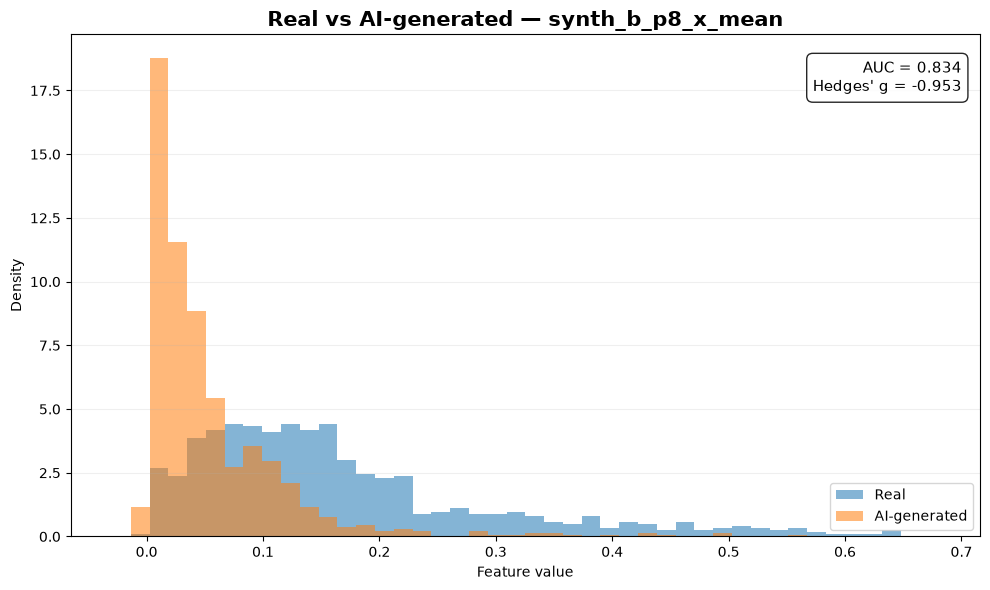

In [22]:
# ============================================================
# CELL 2 — Strongest feature: distribution
# ============================================================

feature = stats_df.iloc[0]["feature"]

real = numeric_df.loc[
    raw_df["label"].eq("real"), feature
].to_numpy(dtype=float)

fake = numeric_df.loc[
    raw_df["label"].eq("fake"), feature
].to_numpy(dtype=float)

real = real[np.isfinite(real)]
fake = fake[np.isfinite(fake)]

# Robust plotting range — does NOT modify the original data.
combined = np.concatenate([real, fake])

low, high = np.percentile(
    combined,
    [1, 99]
)

# Add a small margin.
margin = (high - low) * 0.05
xmin = low - margin
xmax = high + margin

bins = np.linspace(xmin, xmax, 45)

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    real,
    bins=bins,
    density=True,
    alpha=0.55,
    label="Real"
)

ax.hist(
    fake,
    bins=bins,
    density=True,
    alpha=0.55,
    label="AI-generated"
)

row = stats_df.loc[
    stats_df["feature"].eq(feature)
].iloc[0]

ax.set_title(
    f"Real vs AI-generated — {feature}",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Feature value")
ax.set_ylabel("Density")

ax.text(
    0.98,
    0.95,
    f"AUC = {row['roc_auc_separation']:.3f}\n"
    f"Hedges' g = {row['hedges_g']:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85
    )
)

ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_01_strongest_feature_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

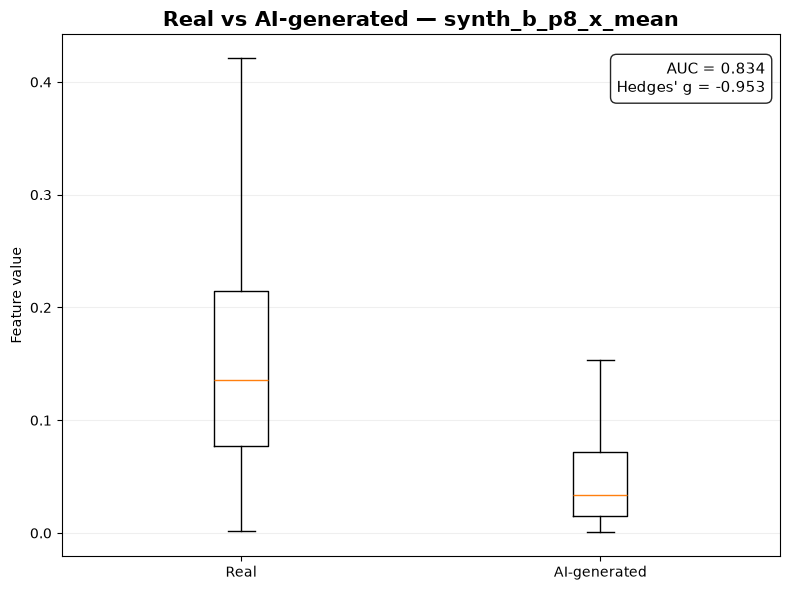

In [23]:
# ============================================================
# CELL 3 — Strongest feature: boxplot
# ============================================================

feature = stats_df.iloc[0]["feature"]

real = numeric_df.loc[
    raw_df["label"].eq("real"), feature
].to_numpy(dtype=float)

fake = numeric_df.loc[
    raw_df["label"].eq("fake"), feature
].to_numpy(dtype=float)

real = real[np.isfinite(real)]
fake = fake[np.isfinite(fake)]

fig, ax = plt.subplots(figsize=(8, 6))

ax.boxplot(
    [real, fake],
    tick_labels=["Real", "AI-generated"],
    showfliers=False
)

row = stats_df.loc[
    stats_df["feature"].eq(feature)
].iloc[0]

ax.set_title(
    f"Real vs AI-generated — {feature}",
    fontsize=15,
    fontweight="bold"
)

ax.set_ylabel("Feature value")

ax.text(
    0.98,
    0.95,
    f"AUC = {row['roc_auc_separation']:.3f}\n"
    f"Hedges' g = {row['hedges_g']:.3f}",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=11,
    bbox=dict(
        boxstyle="round,pad=0.4",
        facecolor="white",
        alpha=0.85
    )
)

ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_02_strongest_feature_boxplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

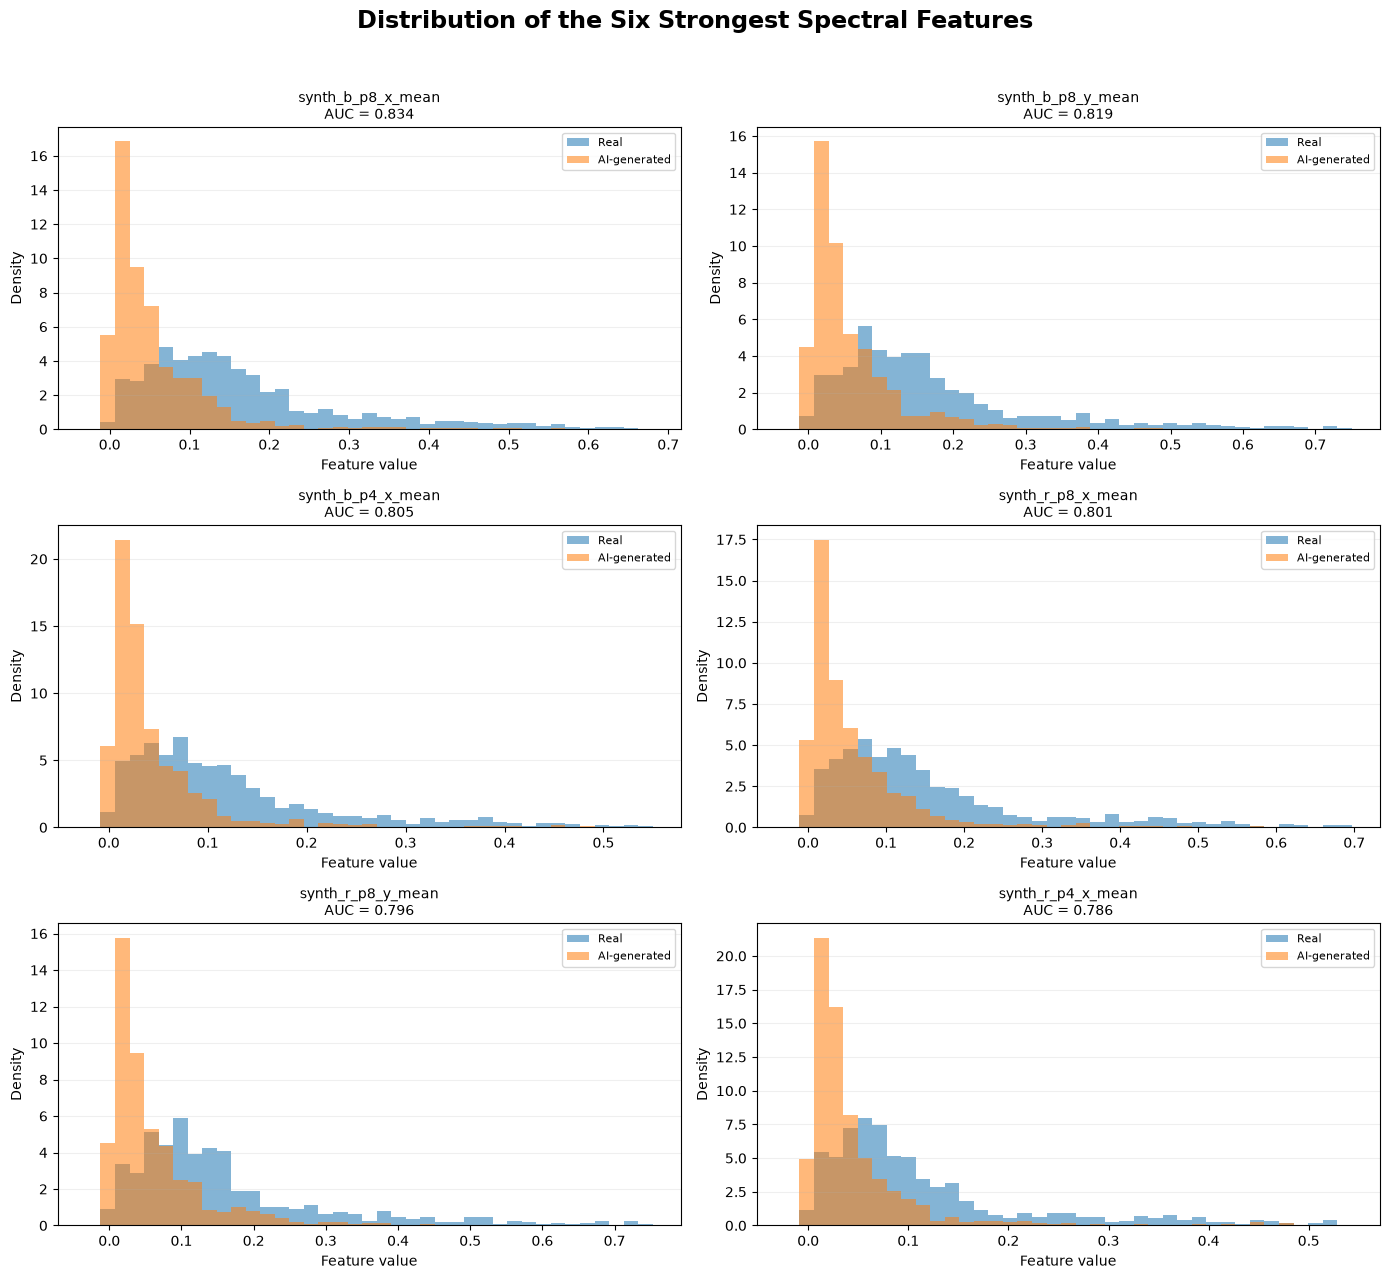

In [24]:
# ============================================================
# CELL 4 — Top 6 spectral features
# ============================================================

top_features = (
    stats_df[
        stats_df["family"].str.contains(
            "FFT|spectral|Synth",
            case=False,
            regex=True,
            na=False
        )
    ]
    .head(6)["feature"]
    .tolist()
)

fig, axes = plt.subplots(
    3,
    2,
    figsize=(14, 13)
)

axes = axes.ravel()

for ax, feature in zip(axes, top_features):

    real = numeric_df.loc[
        raw_df["label"].eq("real"), feature
    ].to_numpy(dtype=float)

    fake = numeric_df.loc[
        raw_df["label"].eq("fake"), feature
    ].to_numpy(dtype=float)

    real = real[np.isfinite(real)]
    fake = fake[np.isfinite(fake)]

    combined = np.concatenate([real, fake])

    low, high = np.percentile(
        combined,
        [1, 99]
    )

    margin = (high - low) * 0.05

    bins = np.linspace(
        low - margin,
        high + margin,
        40
    )

    ax.hist(
        real,
        bins=bins,
        density=True,
        alpha=0.55,
        label="Real"
    )

    ax.hist(
        fake,
        bins=bins,
        density=True,
        alpha=0.55,
        label="AI-generated"
    )

    row = stats_df.loc[
        stats_df["feature"].eq(feature)
    ].iloc[0]

    ax.set_title(
        f"{feature}\nAUC = {row['roc_auc_separation']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Feature value")
    ax.set_ylabel("Density")
    ax.grid(axis="y", alpha=0.2)

    ax.legend(fontsize=8)

plt.suptitle(
    "Distribution of the Six Strongest Spectral Features",
    fontsize=17,
    fontweight="bold"
)

plt.tight_layout(rect=[0, 0, 1, 0.96])

fig.savefig(
    OUT_DIR / "plot_03_top_6_spectral_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

In [25]:
# ============================================================
# CELL 5 — Best feature from each forensic family
# ============================================================

family_best = (
    stats_df
    .sort_values(
        ["family", "roc_auc_separation"],
        ascending=[True, False]
    )
    .groupby("family", sort=False)
    .first()
    .reset_index()
)

family_best = family_best.sort_values(
    "roc_auc_separation",
    ascending=False
)

display(
    family_best[
        [
            "family",
            "feature",
            "roc_auc_separation",
            "hedges_g"
        ]
    ]
)

,family,feature,roc_auc_separation,hedges_g
5,FFT / spectral,synth_b_p8_x_mean,0.834367,-0.952796
8,QWT,qwt_HH1_magnitude_std,0.742784,-0.831499
9,Residual,crossdiff_std,0.737819,-0.802643
2,DWT,HH1_energy,0.737055,-0.581422
7,LBP,lbp_mean_code,0.719264,-0.792672
4,Edges / gradients,laplacian_absmean,0.704922,-0.667474
1,DCT,dct_highfreq_ratio_mean,0.696294,-0.412327
3,ELA,ela_std,0.684026,-0.543207
6,GLCM,glcm_energy_std,0.678233,0.597176
0,Color / intensity,b_entropy,0.597217,-0.299886


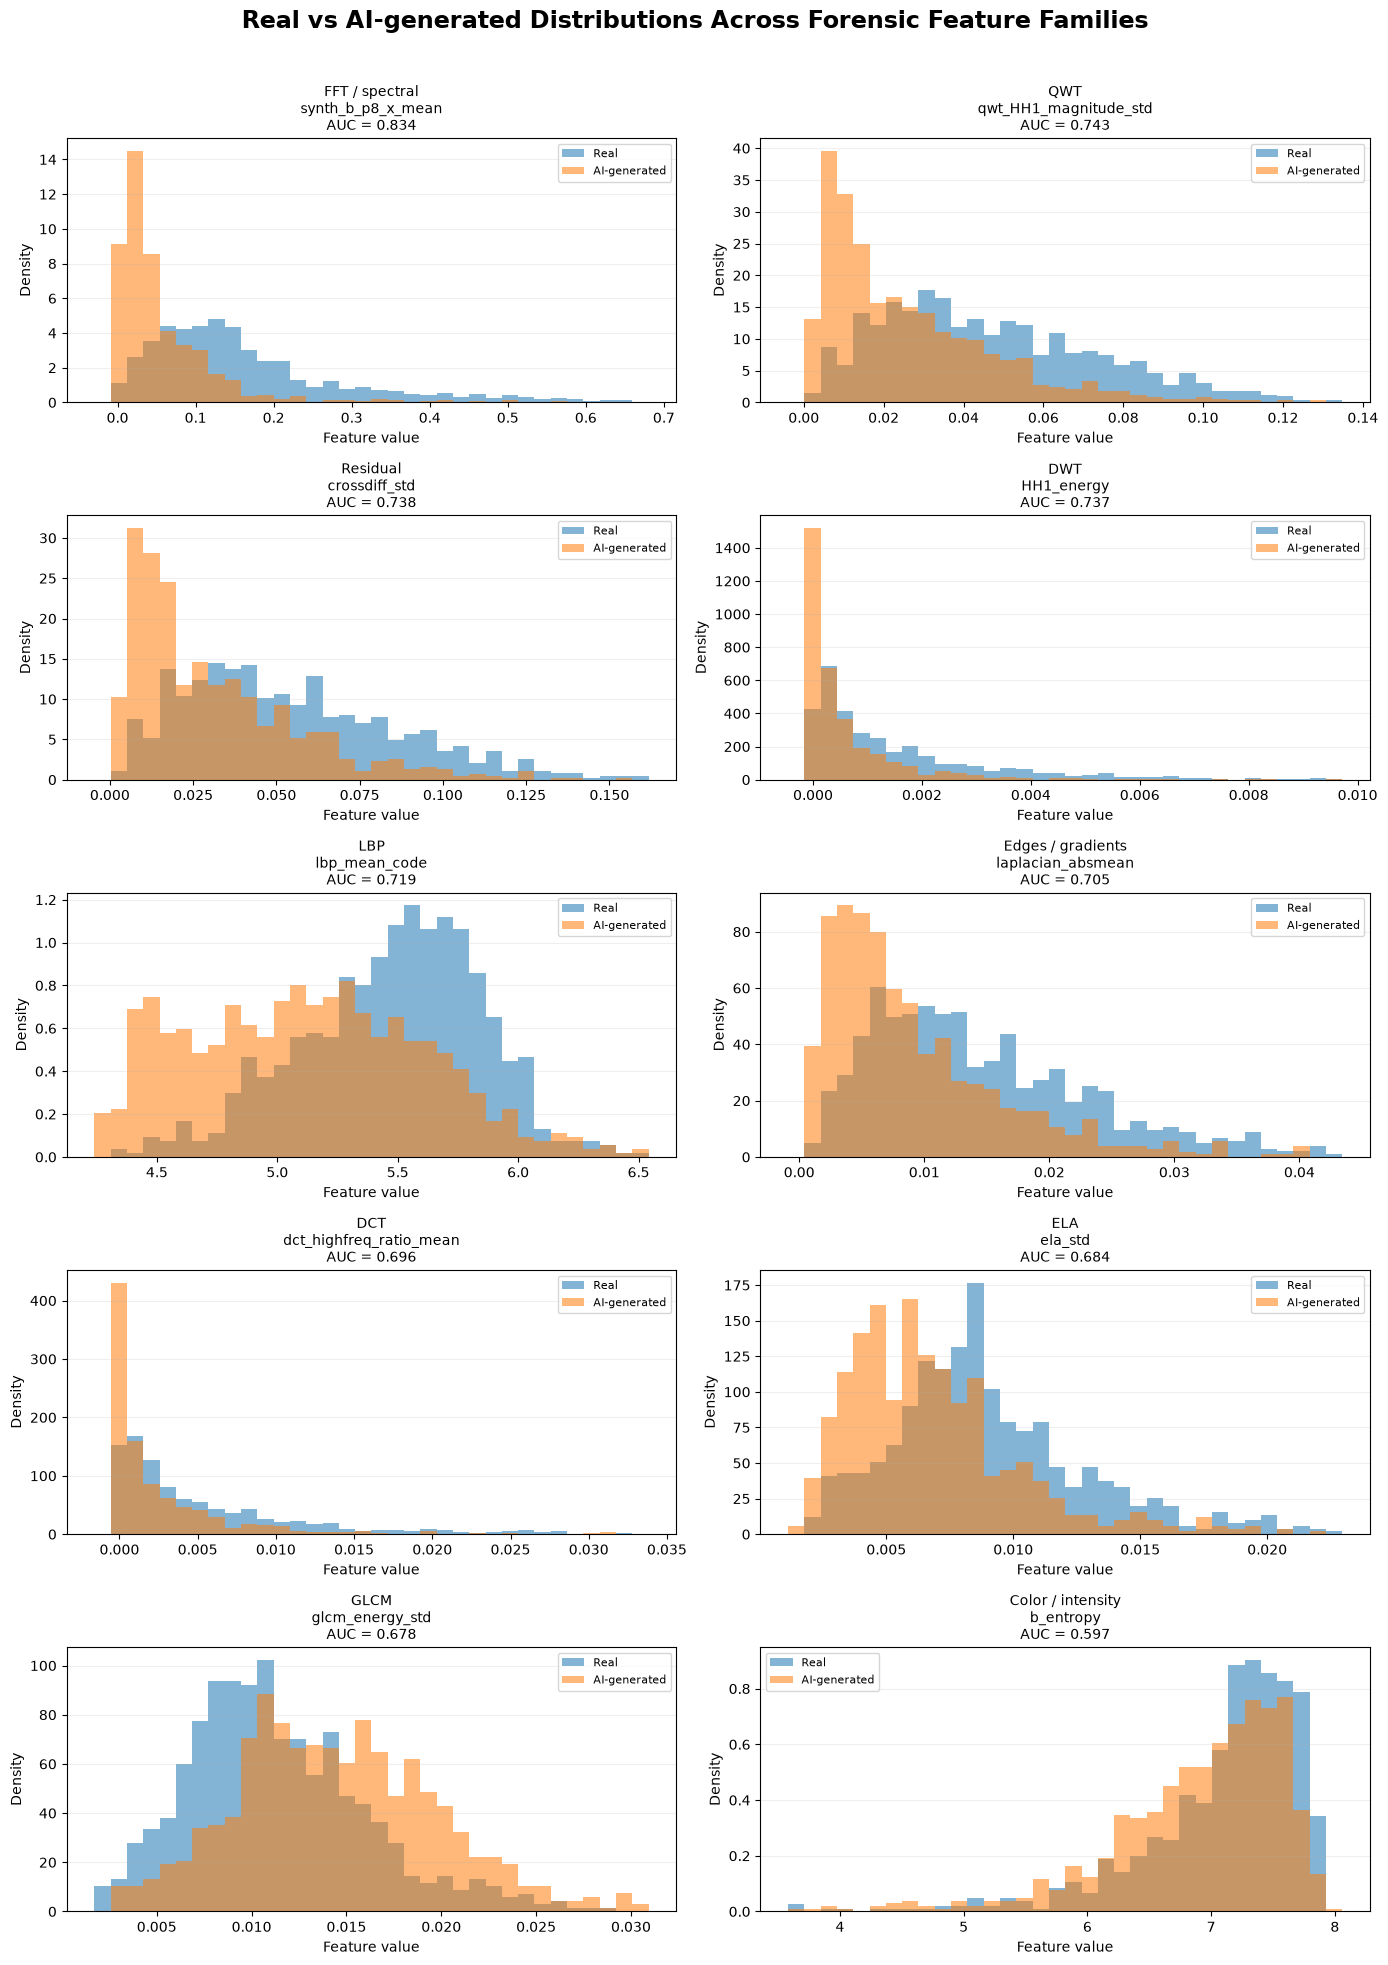

In [26]:
# ============================================================
# CELL 6 — Best feature from each forensic family
# ============================================================

features = family_best["feature"].tolist()

n = len(features)

fig, axes = plt.subplots(
    nrows=int(np.ceil(n / 2)),
    ncols=2,
    figsize=(14, 4 * int(np.ceil(n / 2)))
)

axes = np.asarray(axes).ravel()

for ax, feature in zip(axes, features):

    real = numeric_df.loc[
        raw_df["label"].eq("real"), feature
    ].to_numpy(dtype=float)

    fake = numeric_df.loc[
        raw_df["label"].eq("fake"), feature
    ].to_numpy(dtype=float)

    real = real[np.isfinite(real)]
    fake = fake[np.isfinite(fake)]

    combined = np.concatenate([real, fake])

    low, high = np.percentile(
        combined,
        [1, 99]
    )

    margin = (high - low) * 0.05

    bins = np.linspace(
        low - margin,
        high + margin,
        35
    )

    ax.hist(
        real,
        bins=bins,
        density=True,
        alpha=0.55,
        label="Real"
    )

    ax.hist(
        fake,
        bins=bins,
        density=True,
        alpha=0.55,
        label="AI-generated"
    )

    row = stats_df.loc[
        stats_df["feature"].eq(feature)
    ].iloc[0]

    ax.set_title(
        f"{row['family']}\n{feature}\n"
        f"AUC = {row['roc_auc_separation']:.3f}",
        fontsize=10
    )

    ax.set_xlabel("Feature value")
    ax.set_ylabel("Density")

    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=8)

# Hide unused axes.
for ax in axes[len(features):]:
    ax.set_visible(False)

fig.suptitle(
    "Real vs AI-generated Distributions Across Forensic Feature Families",
    fontsize=17,
    fontweight="bold"
)

fig.tight_layout(rect=[0, 0, 1, 0.97])

fig.savefig(
    OUT_DIR / "plot_04_feature_family_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

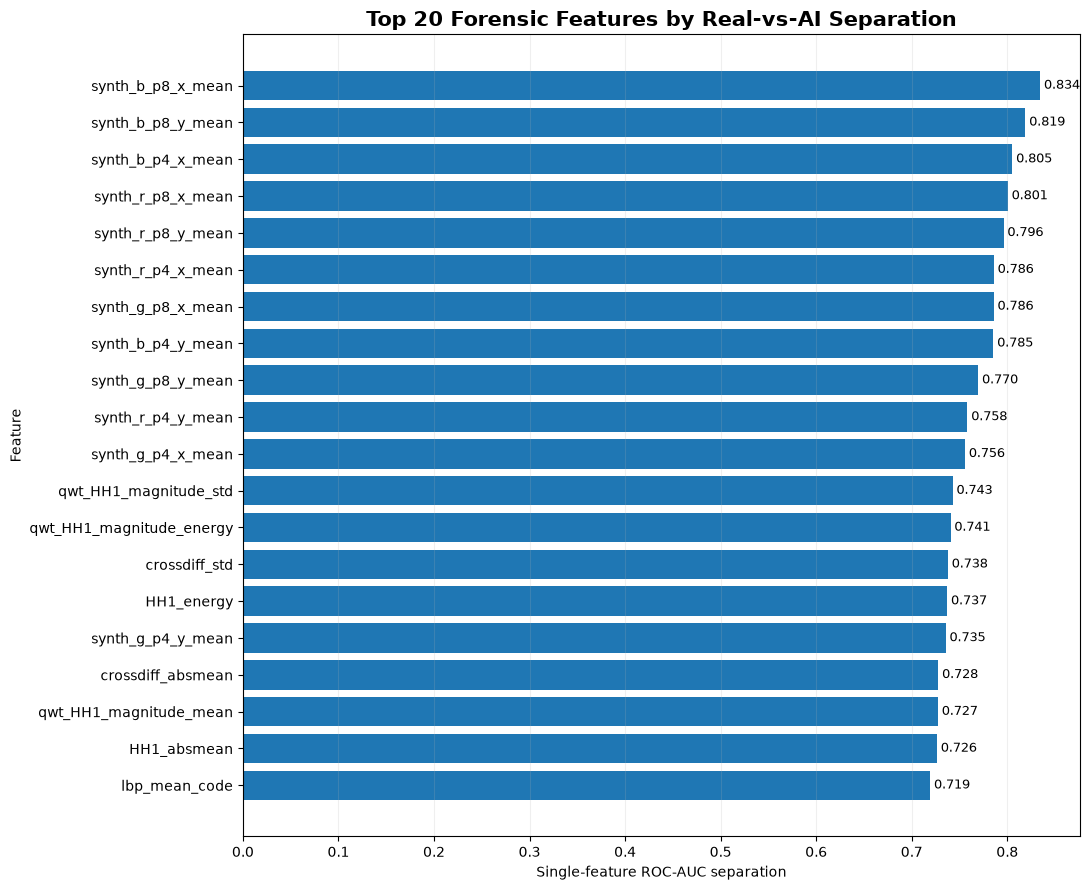

In [27]:
# ============================================================
# CELL 7 — Top 20 features by AUC
# ============================================================

top = (
    stats_df
    .sort_values("roc_auc_separation", ascending=False)
    .head(20)
    .sort_values("roc_auc_separation")
)

fig, ax = plt.subplots(figsize=(11, 9))

ax.barh(
    top["feature"],
    top["roc_auc_separation"]
)

ax.set_xlabel("Single-feature ROC-AUC separation")
ax.set_ylabel("Feature")

ax.set_title(
    "Top 20 Forensic Features by Real-vs-AI Separation",
    fontsize=15,
    fontweight="bold"
)

for i, value in enumerate(
    top["roc_auc_separation"]
):
    ax.text(
        value + 0.004,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_05_top_20_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

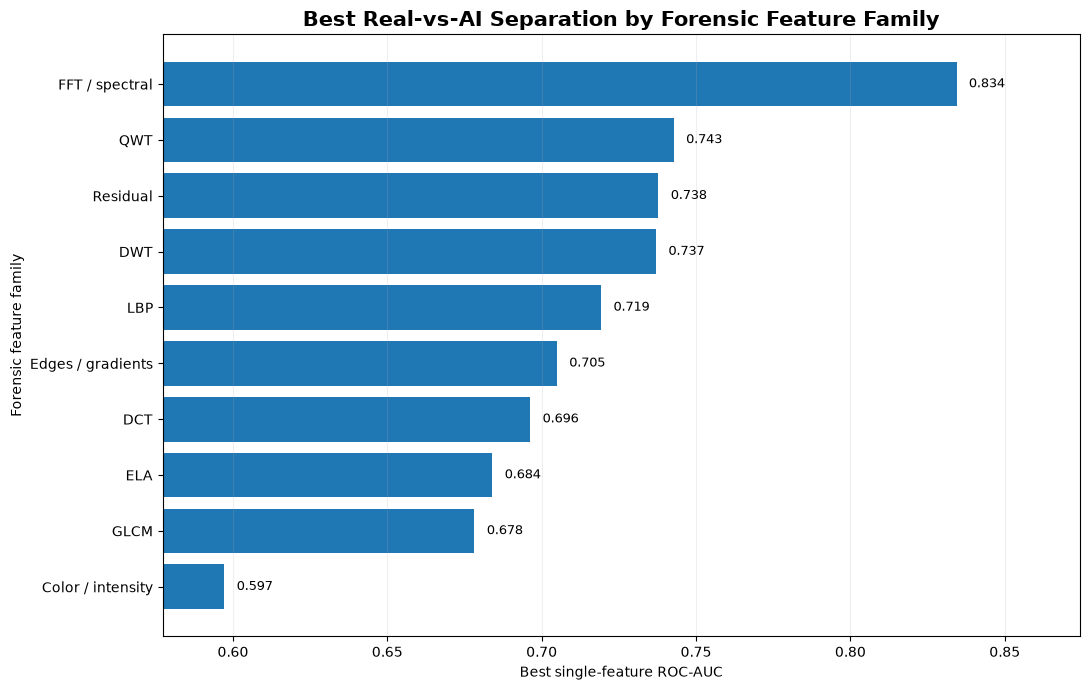

In [28]:
# ============================================================
# CELL 8 — Best AUC by forensic family
# ============================================================

family_auc = (
    stats_df
    .groupby("family")["roc_auc_separation"]
    .max()
    .sort_values()
)

fig, ax = plt.subplots(figsize=(11, 7))

ax.barh(
    family_auc.index,
    family_auc.values
)

ax.set_xlabel("Best single-feature ROC-AUC")
ax.set_ylabel("Forensic feature family")

ax.set_title(
    "Best Real-vs-AI Separation by Forensic Feature Family",
    fontsize=15,
    fontweight="bold"
)

for i, value in enumerate(family_auc.values):
    ax.text(
        value + 0.004,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=9
    )

ax.set_xlim(
    max(0.5, family_auc.min() - 0.02),
    min(1.0, family_auc.max() + 0.04)
)

ax.grid(axis="x", alpha=0.2)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_06_feature_family_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

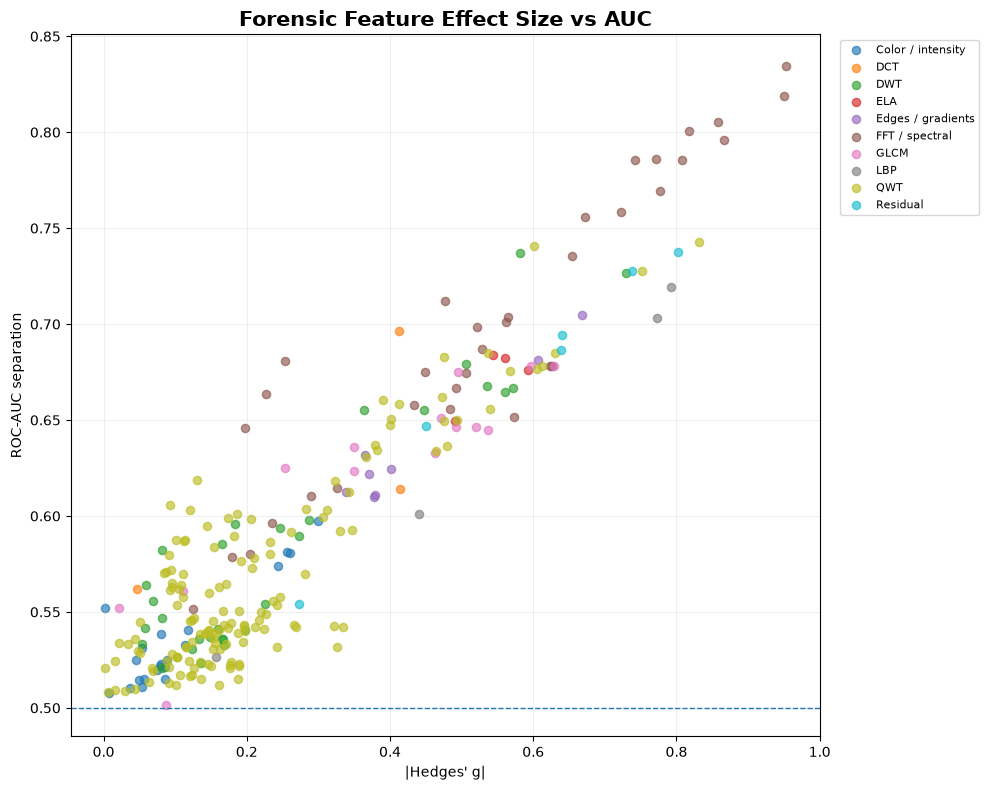

In [29]:
# ============================================================
# CELL 9 — Effect size vs AUC
# ============================================================

plot_df = stats_df.copy()

plot_df["abs_hedges_g"] = plot_df["hedges_g"].abs()

fig, ax = plt.subplots(figsize=(10, 8))

for family, group in plot_df.groupby("family"):

    ax.scatter(
        group["abs_hedges_g"],
        group["roc_auc_separation"],
        s=35,
        alpha=0.65,
        label=family
    )

ax.axhline(
    0.5,
    linestyle="--",
    linewidth=1
)

ax.set_xlabel("|Hedges' g|")
ax.set_ylabel("ROC-AUC separation")

ax.set_title(
    "Forensic Feature Effect Size vs AUC",
    fontsize=15,
    fontweight="bold"
)

ax.grid(alpha=0.2)

ax.legend(
    fontsize=8,
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_07_effect_size_vs_auc.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)

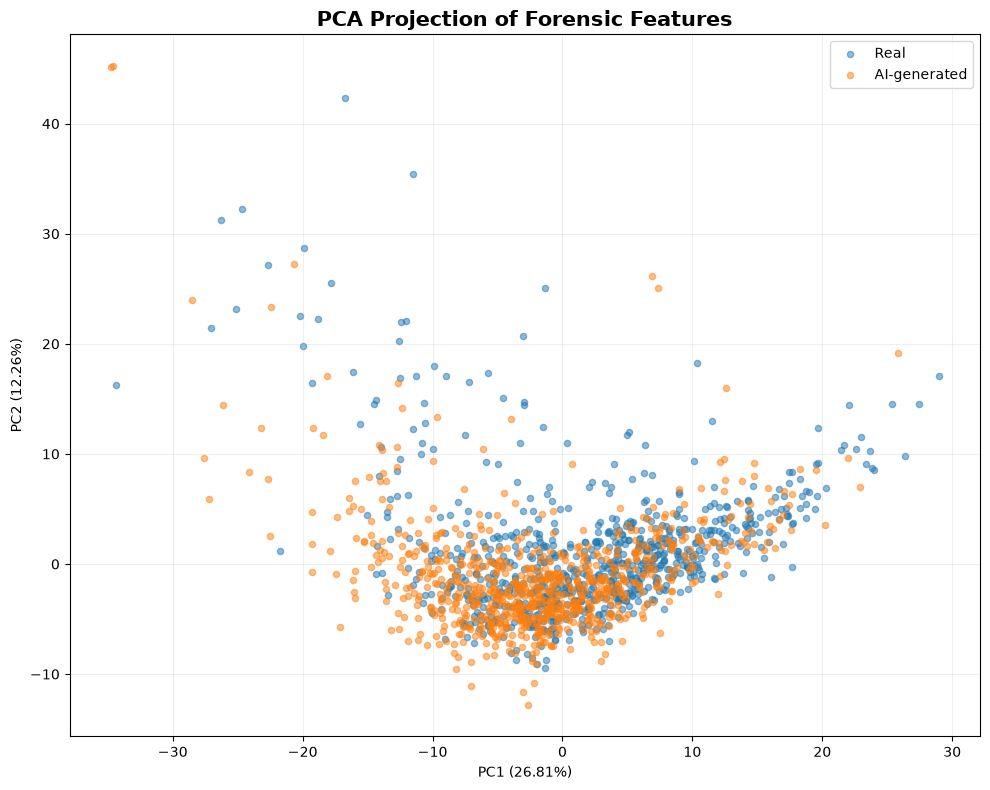

In [30]:
# ============================================================
# CELL 10 — PCA: Real vs AI-generated
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

for label, name in [
    ("real", "Real"),
    ("fake", "AI-generated")
]:

    subset = pca_df[
        pca_df["label"].eq(label)
    ]

    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        s=20,
        alpha=0.5,
        label=name
    )

ax.set_xlabel(
    f"PC1 ({pca.explained_variance_ratio_[0] * 100:.2f}%)"
)

ax.set_ylabel(
    f"PC2 ({pca.explained_variance_ratio_[1] * 100:.2f}%)"
)

ax.set_title(
    "PCA Projection of Forensic Features",
    fontsize=15,
    fontweight="bold"
)

ax.legend()
ax.grid(alpha=0.2)

plt.tight_layout()

fig.savefig(
    OUT_DIR / "plot_08_pca_real_vs_fake.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
plt.close(fig)